ADAPTIVE DBLP COMMUNITY ANALYZER
Target modularity range: [0.3, 0.8]
Parsing DBLP data...
  Processed 10000 papers...
  Processed 20000 papers...
  Processed 30000 papers...
  Processed 40000 papers...
  Processed 50000 papers...
  Processed 60000 papers...
  Processed 70000 papers...
  Processed 80000 papers...
  Processed 90000 papers...
  Processed 100000 papers...
  Processed 110000 papers...
  Processed 120000 papers...
  Processed 130000 papers...
  Processed 140000 papers...
  Processed 150000 papers...
  Processed 160000 papers...
  Processed 170000 papers...
  Processed 180000 papers...
  Processed 190000 papers...
  Processed 200000 papers...
  Processed 210000 papers...
  Processed 220000 papers...
  Processed 230000 papers...
  Processed 240000 papers...
  Processed 250000 papers...
  Processed 260000 papers...
  Processed 270000 papers...
  Processed 280000 papers...
  Processed 290000 papers...
  Processed 300000 papers...
  Processed 310000 papers...
  Processed 320000 p

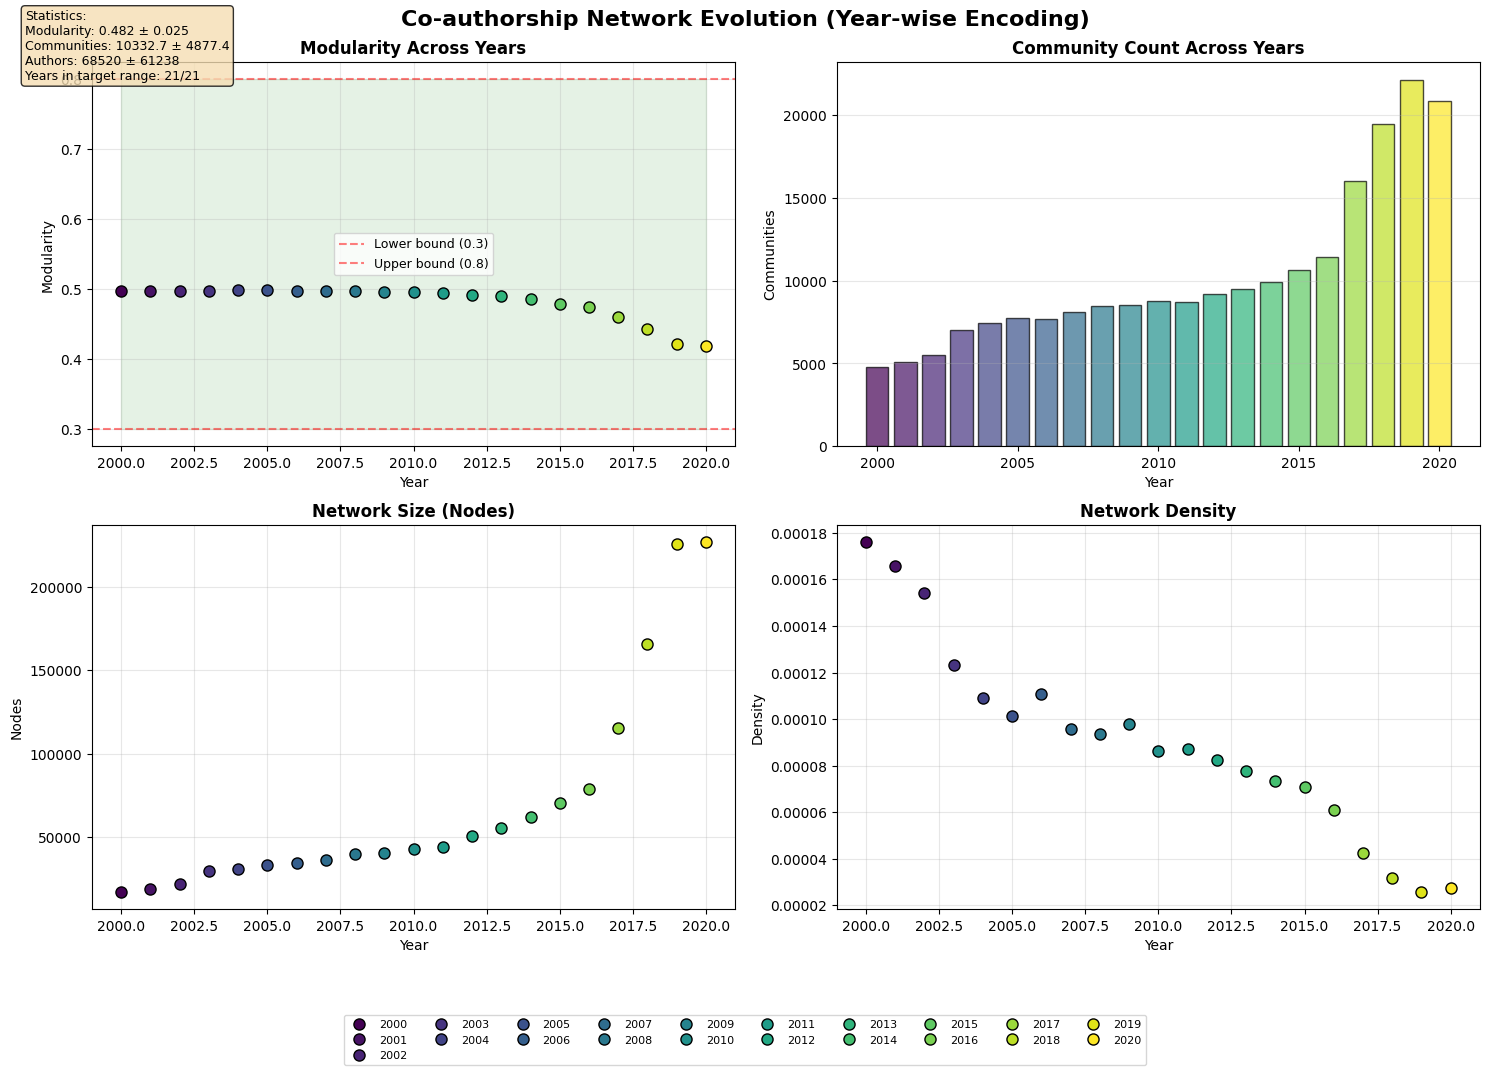


🦠 Creating SIR network visualizations...
   Year 2000...
   Saved SIR visualization: community_viz/sir_year_2000.png


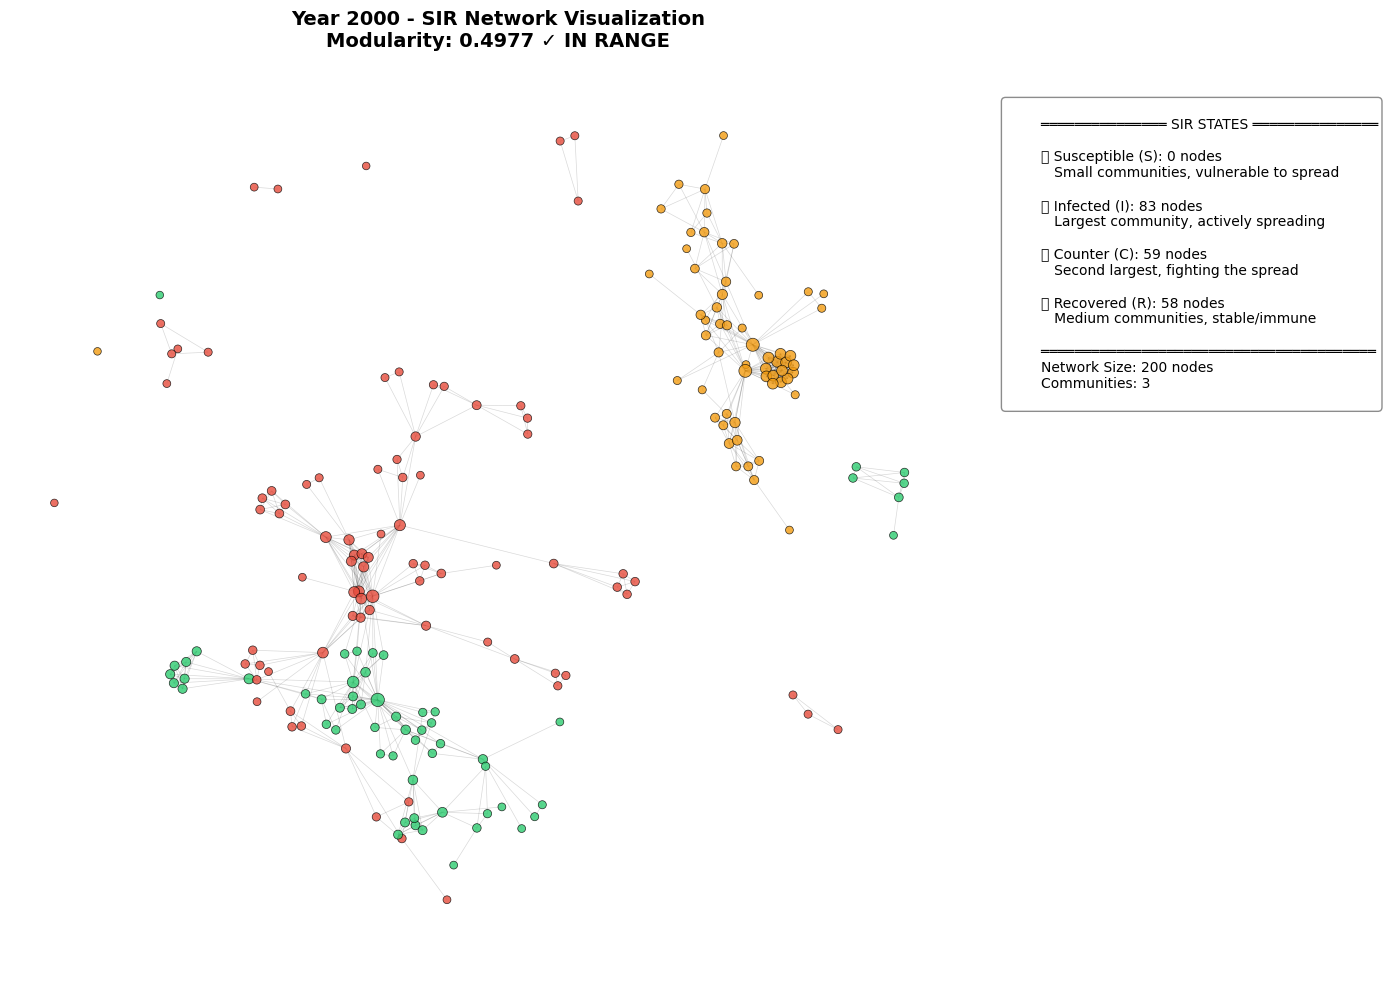

   Year 2001...
   Saved SIR visualization: community_viz/sir_year_2001.png


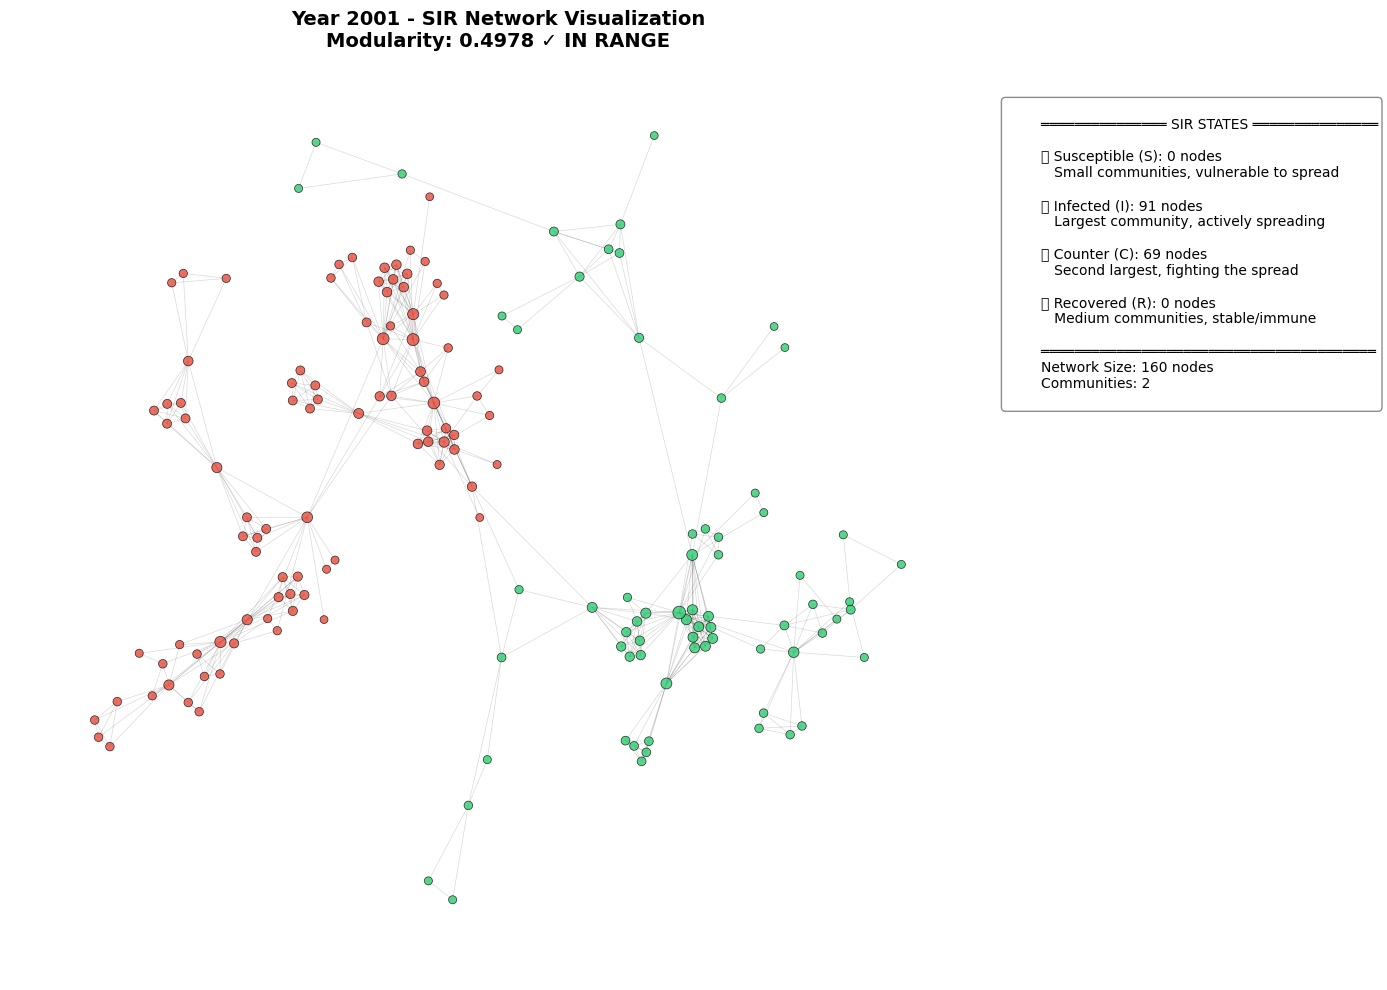

   Year 2002...
   Saved SIR visualization: community_viz/sir_year_2002.png


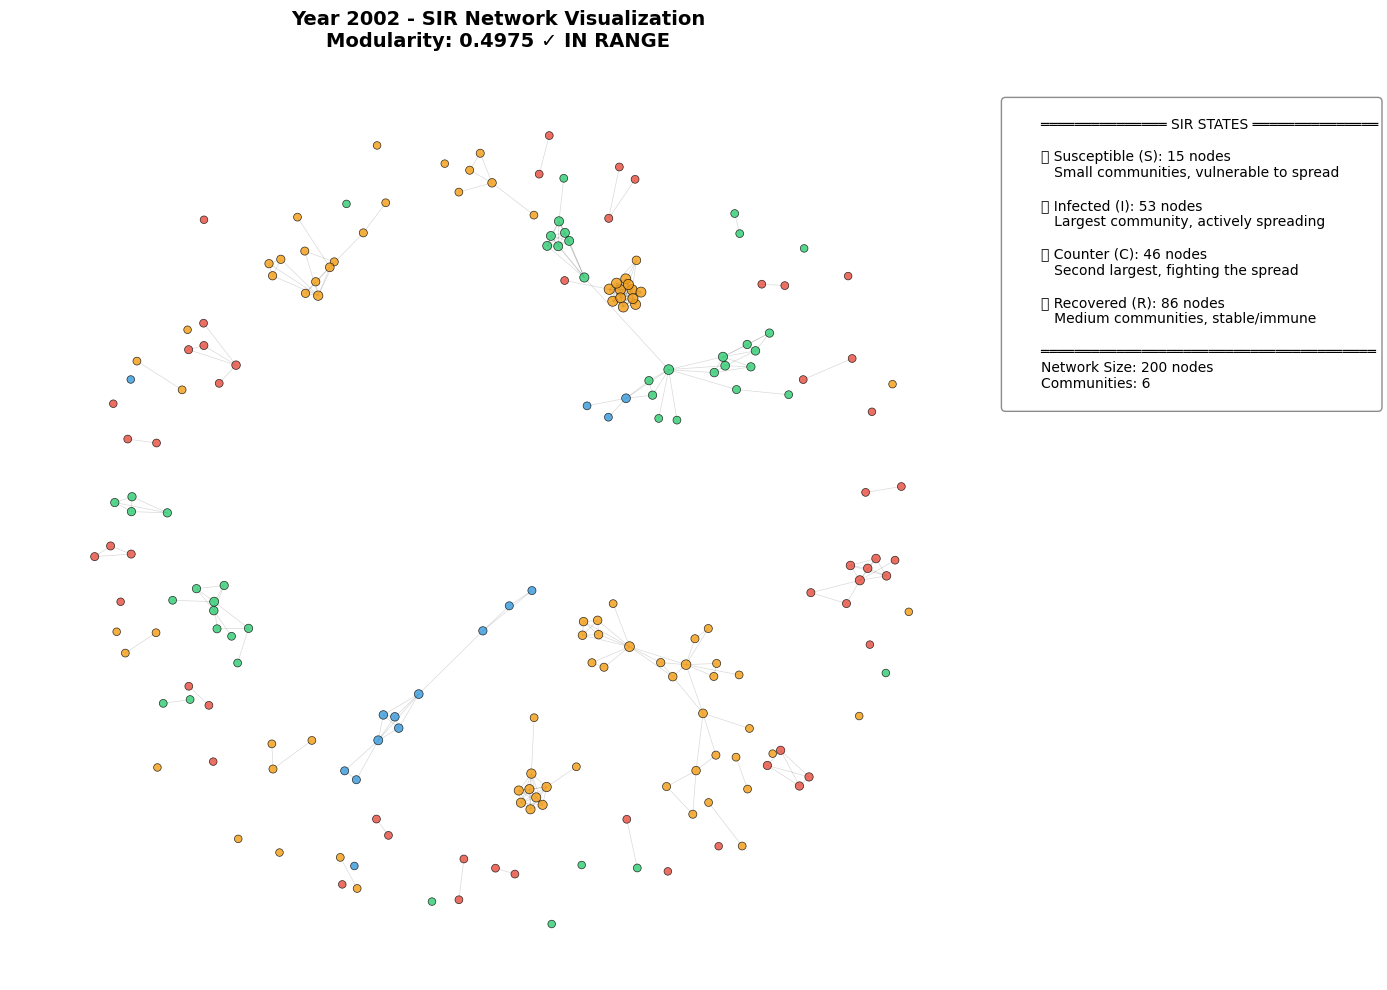

   Year 2003...
   Saved SIR visualization: community_viz/sir_year_2003.png


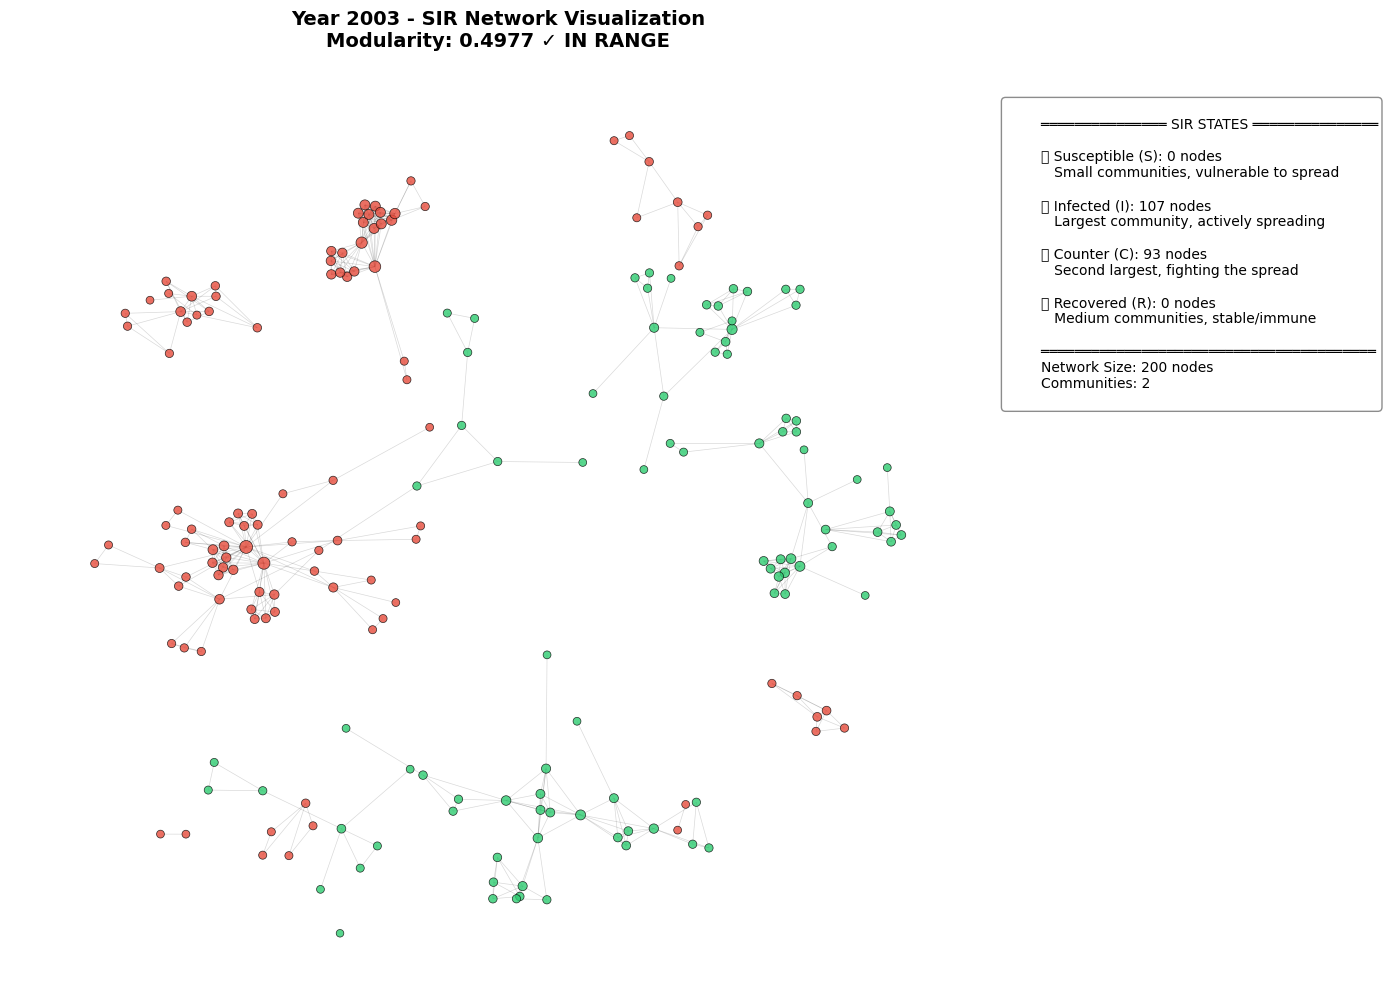

   Year 2004...
   Saved SIR visualization: community_viz/sir_year_2004.png


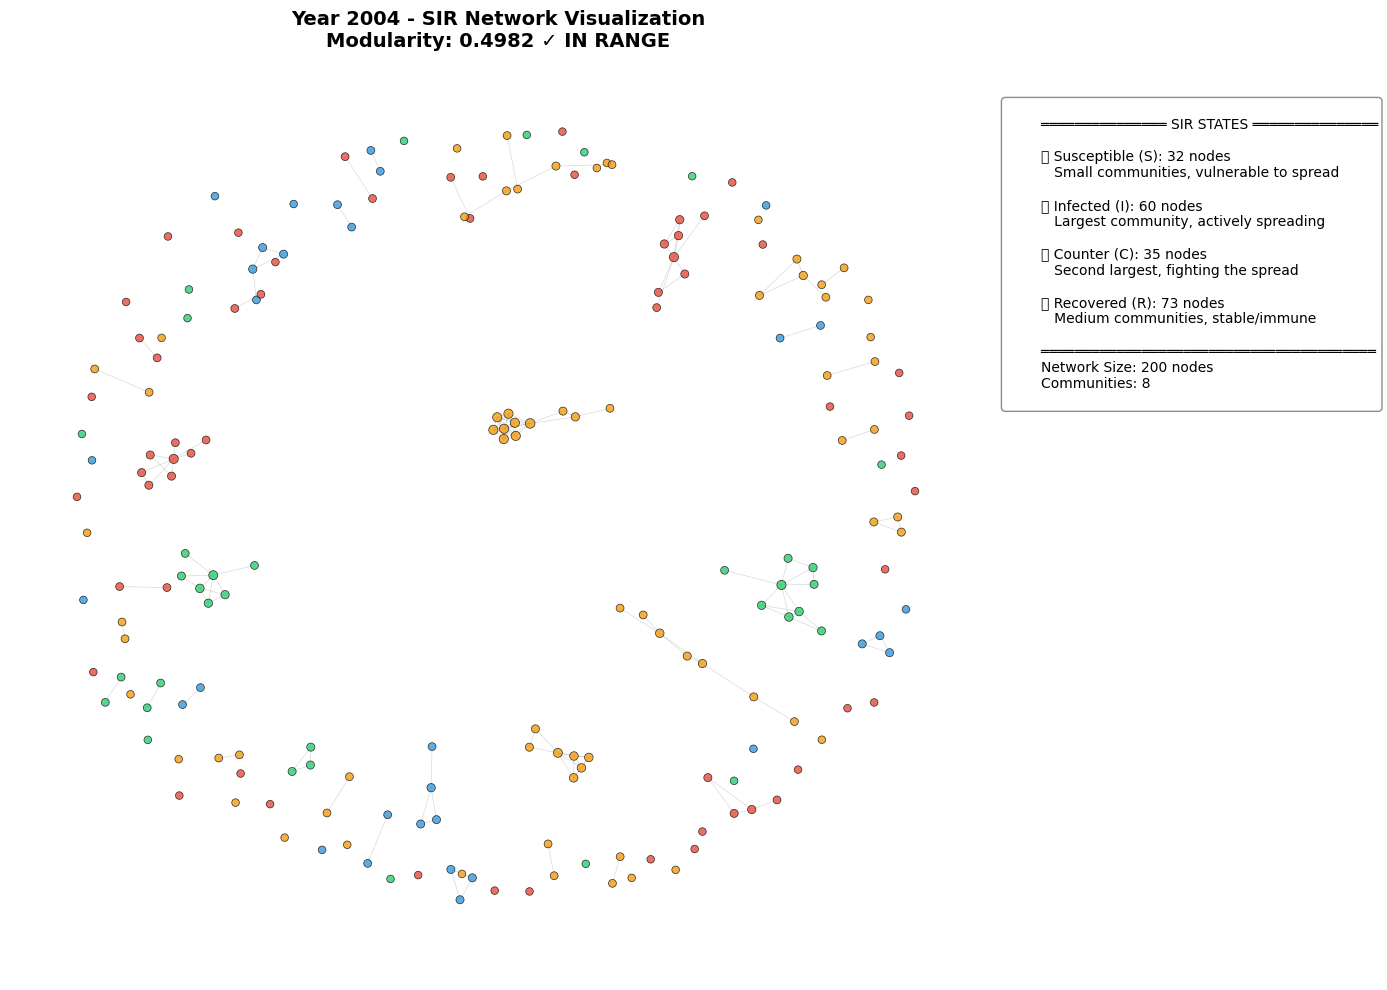

   Year 2005...
   Saved SIR visualization: community_viz/sir_year_2005.png


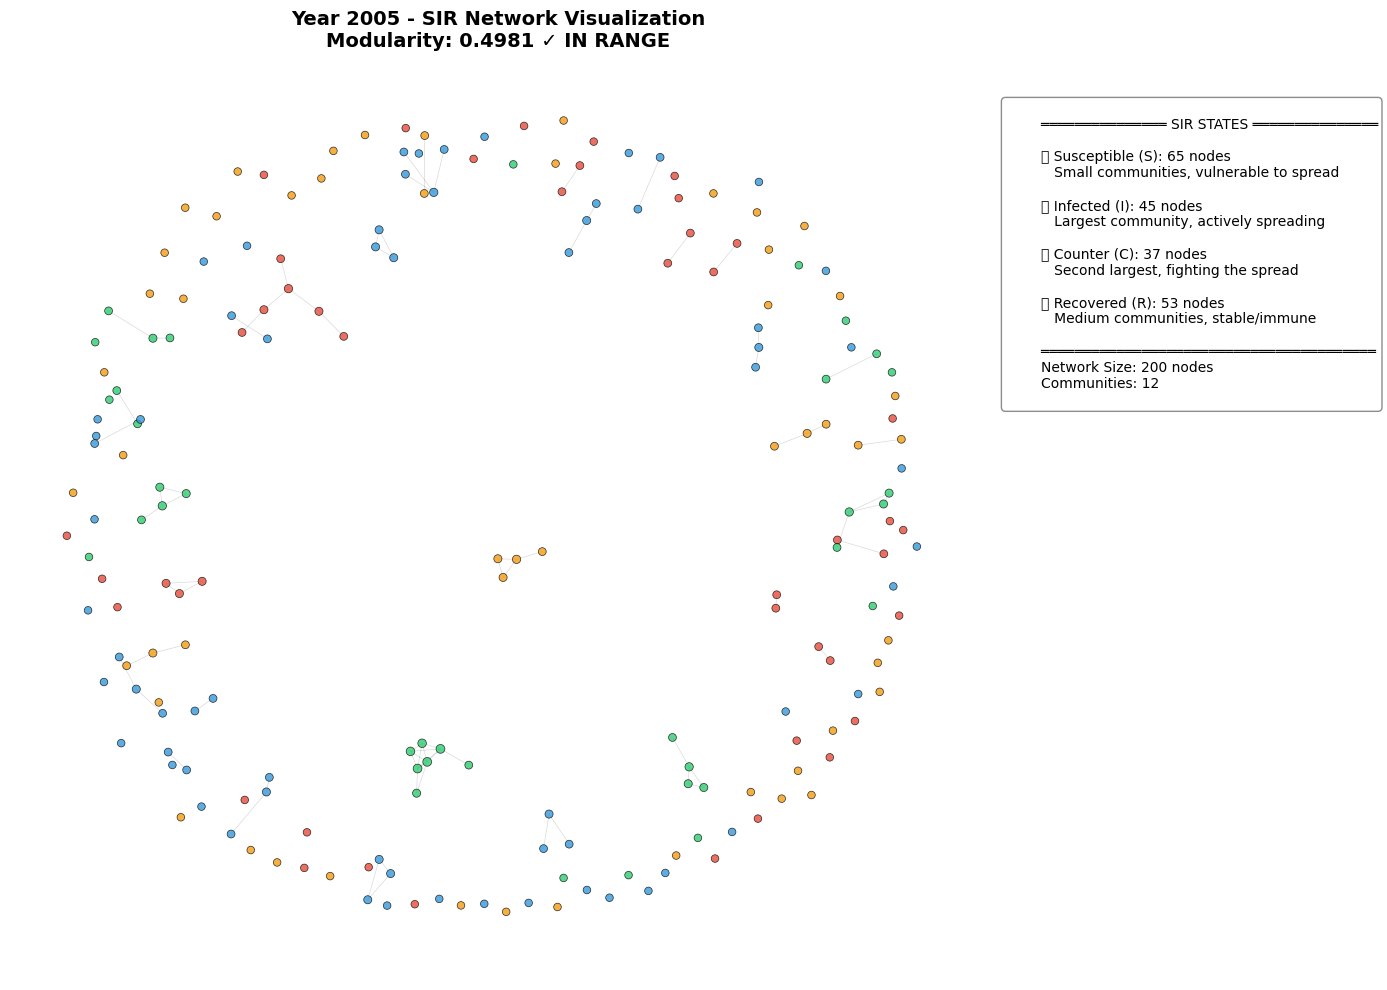

   Year 2006...
   Saved SIR visualization: community_viz/sir_year_2006.png


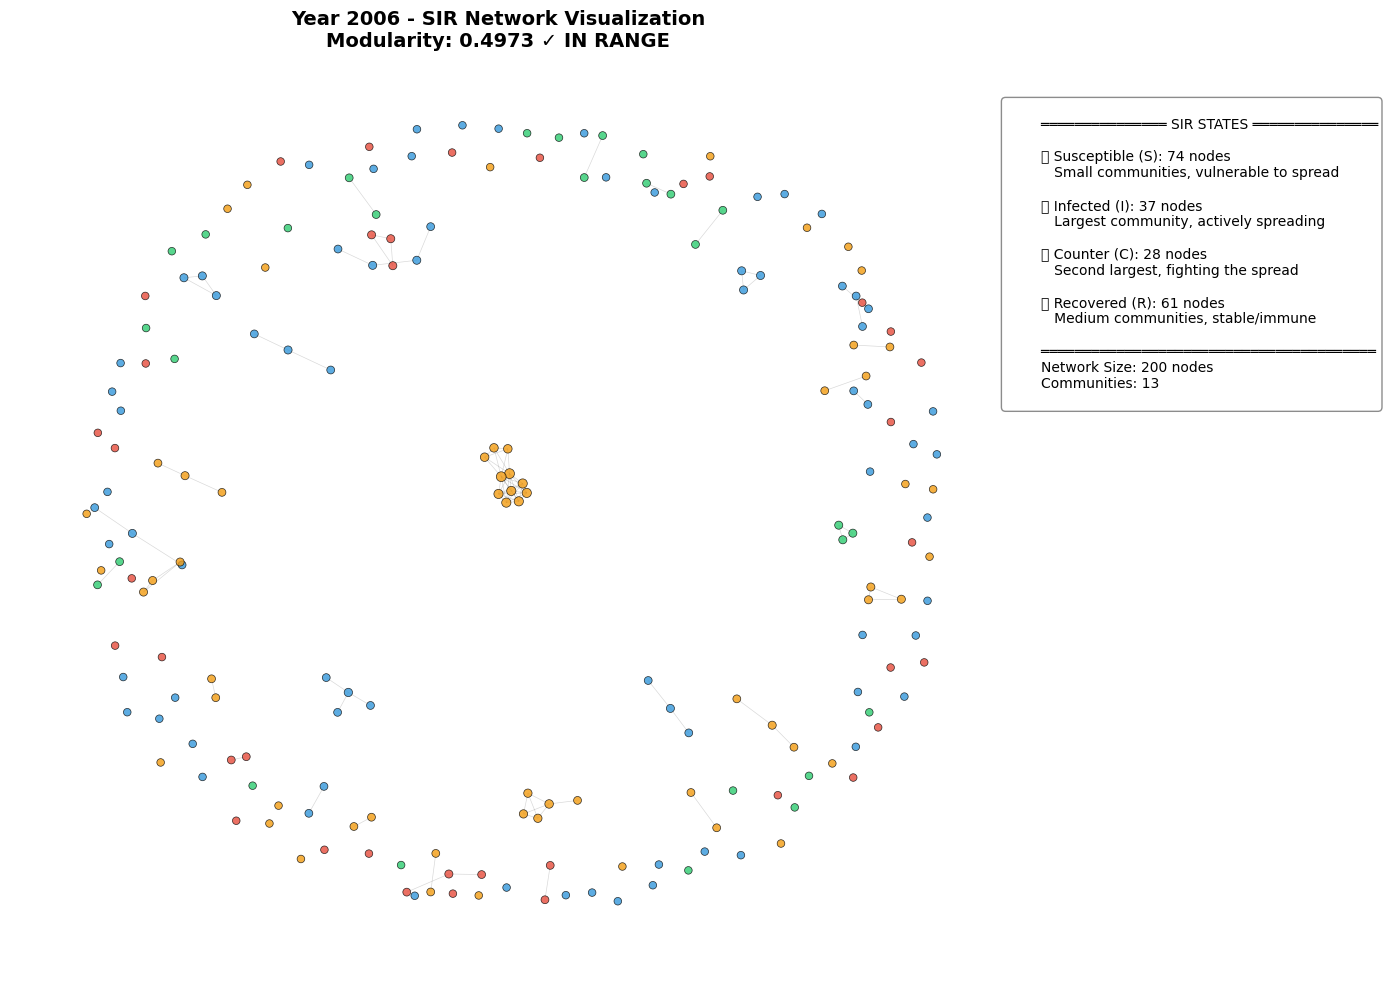

   Year 2007...
   Saved SIR visualization: community_viz/sir_year_2007.png


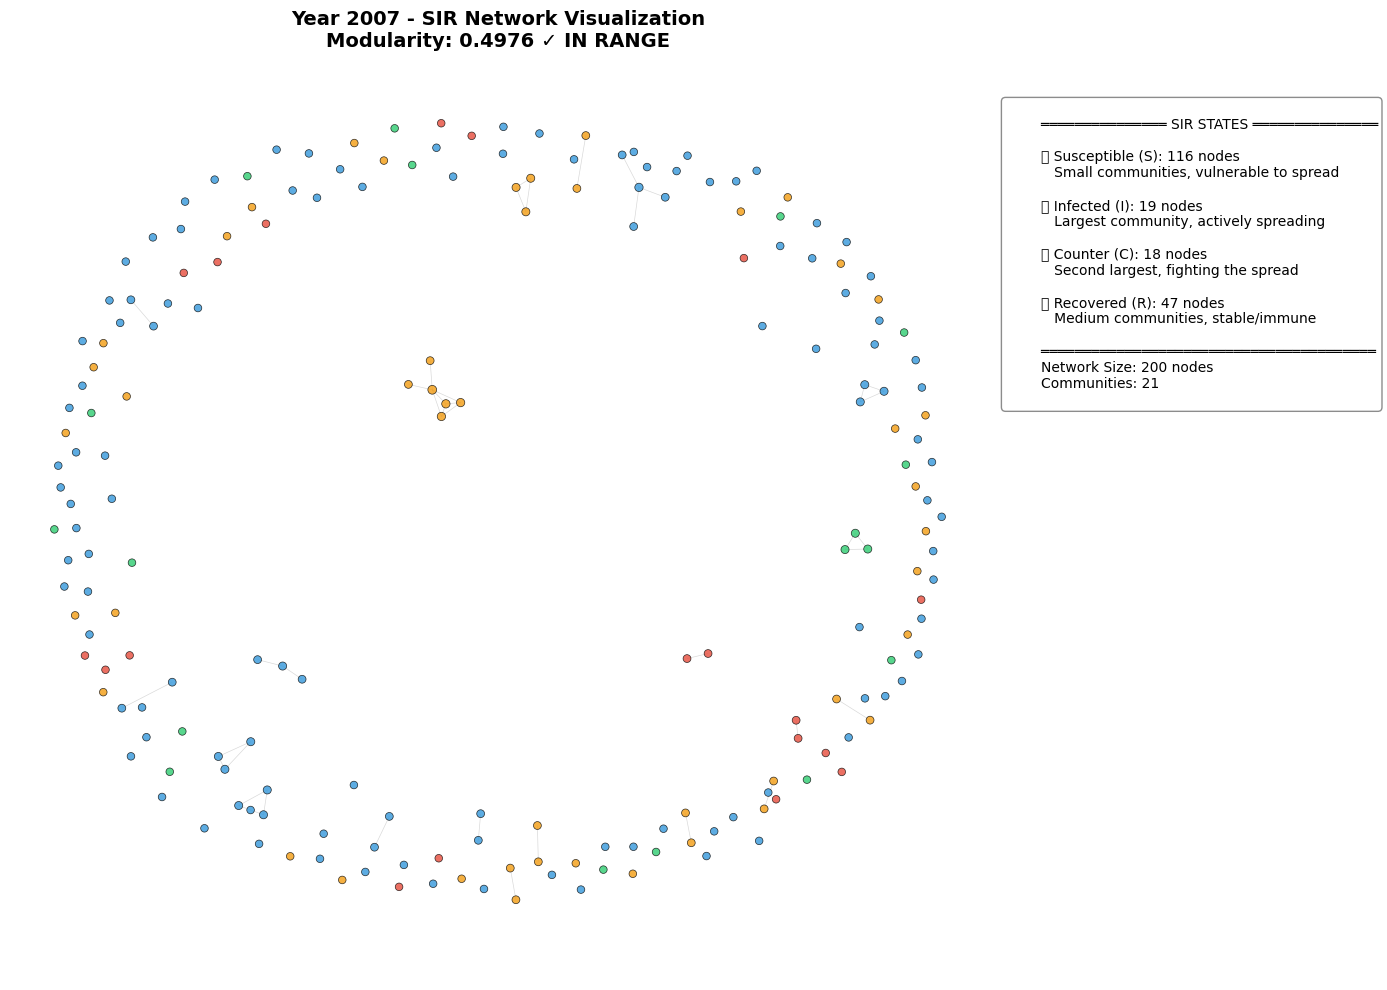

   Year 2008...
   Saved SIR visualization: community_viz/sir_year_2008.png


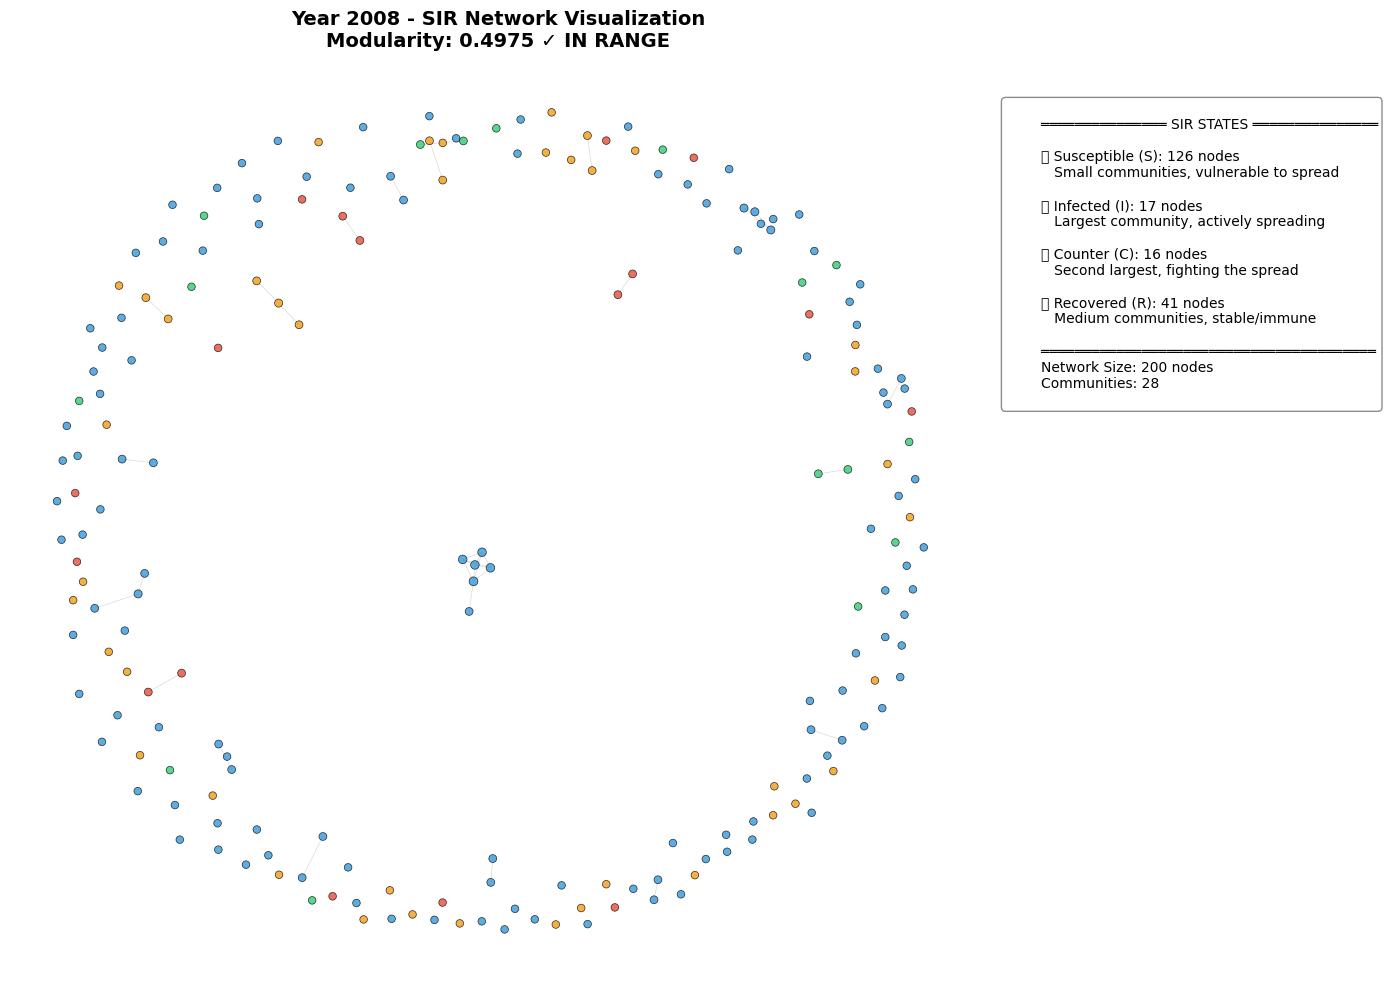

   Year 2009...
   Saved SIR visualization: community_viz/sir_year_2009.png


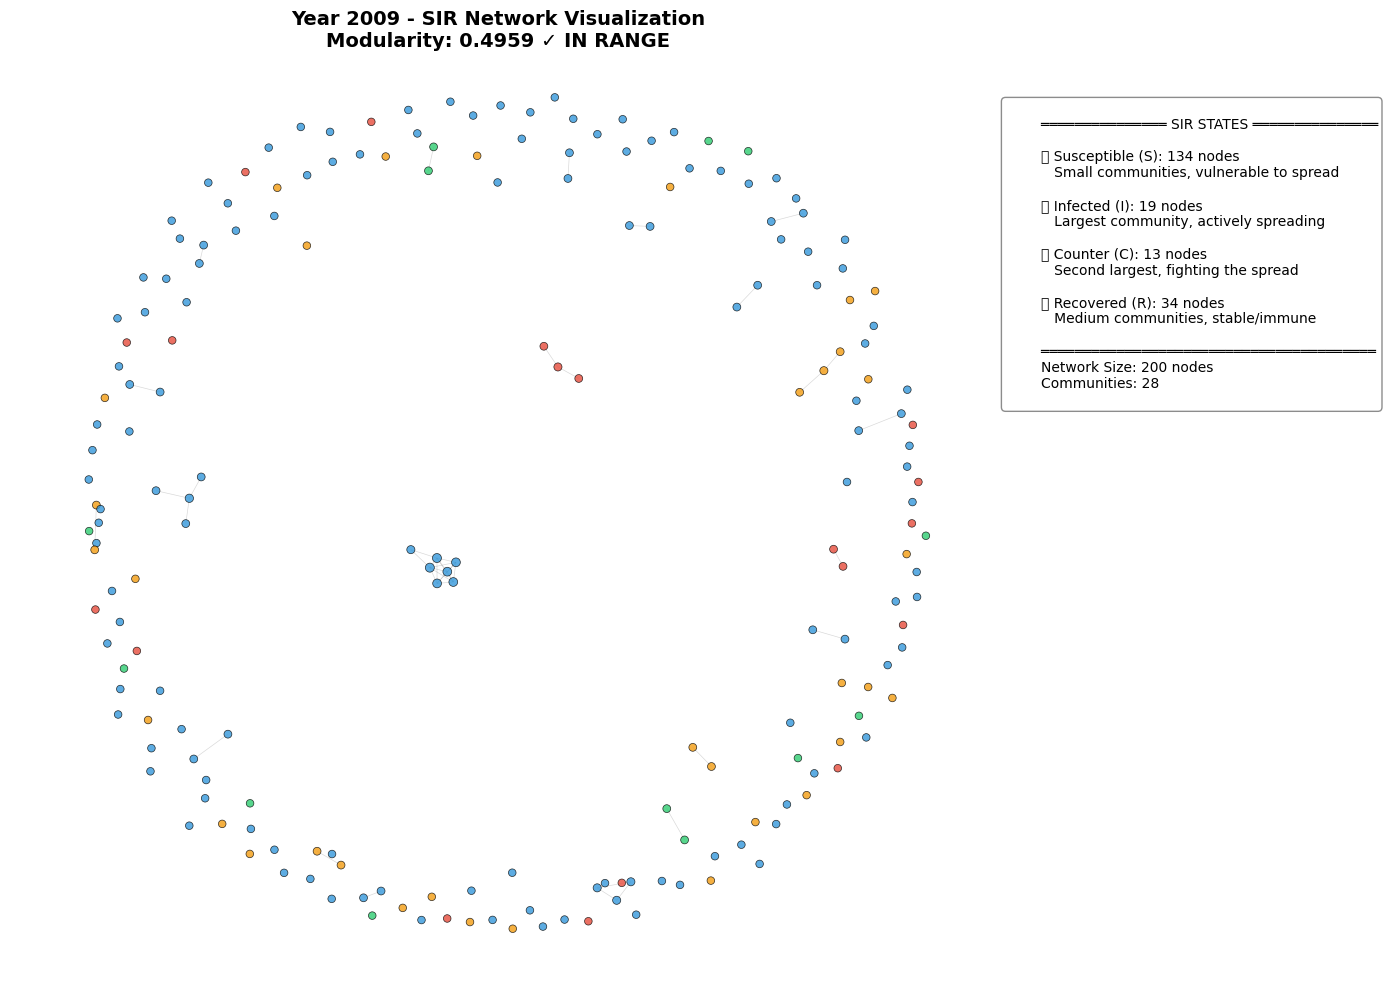

   Year 2010...
   Saved SIR visualization: community_viz/sir_year_2010.png


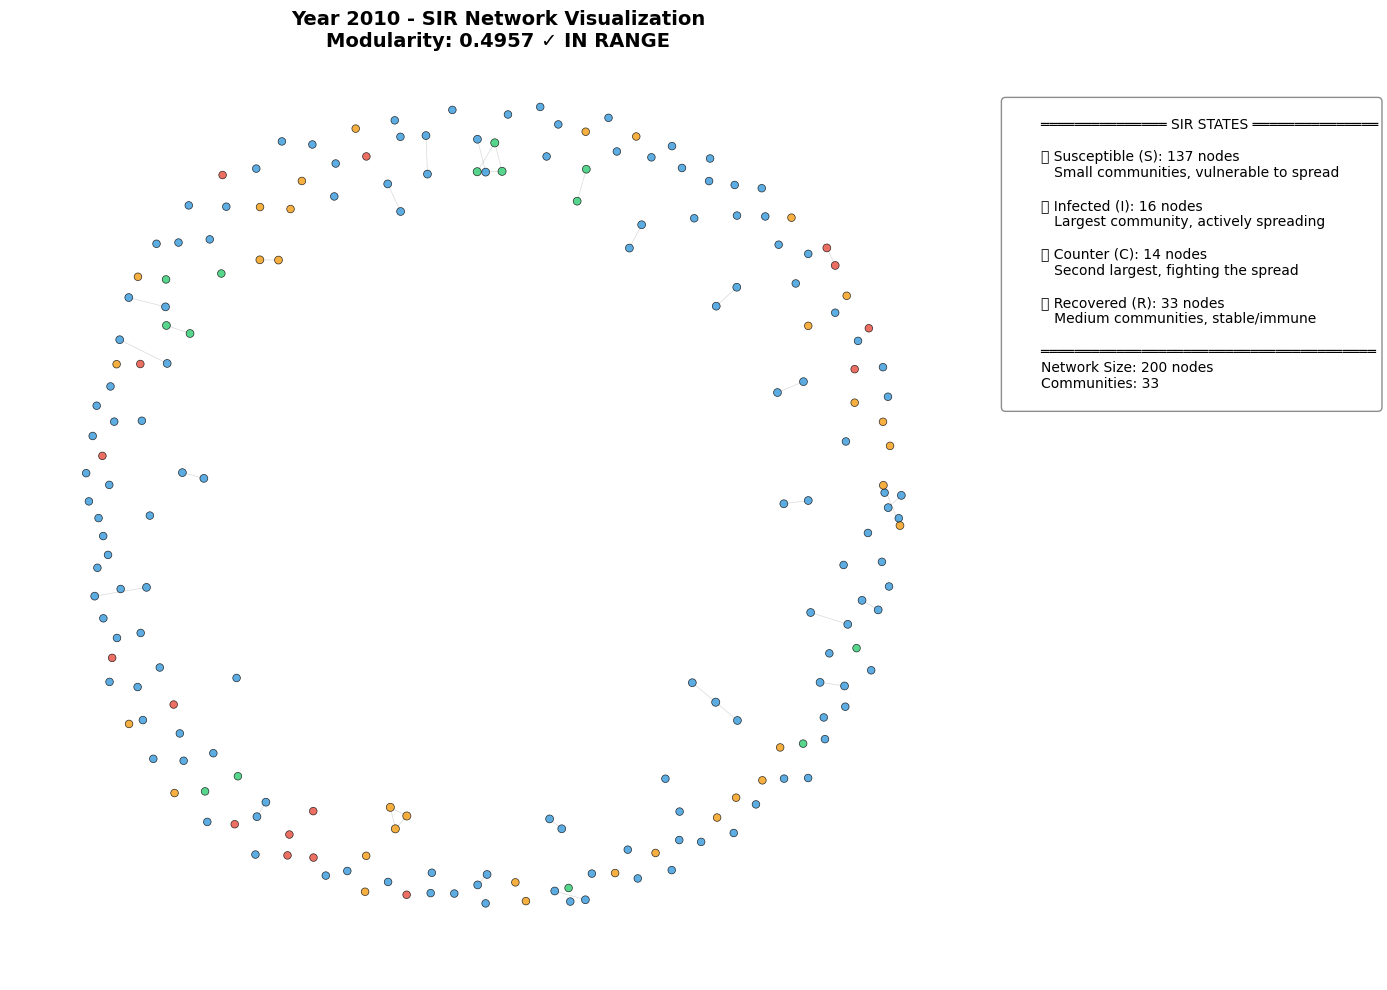

   Year 2011...
   Saved SIR visualization: community_viz/sir_year_2011.png


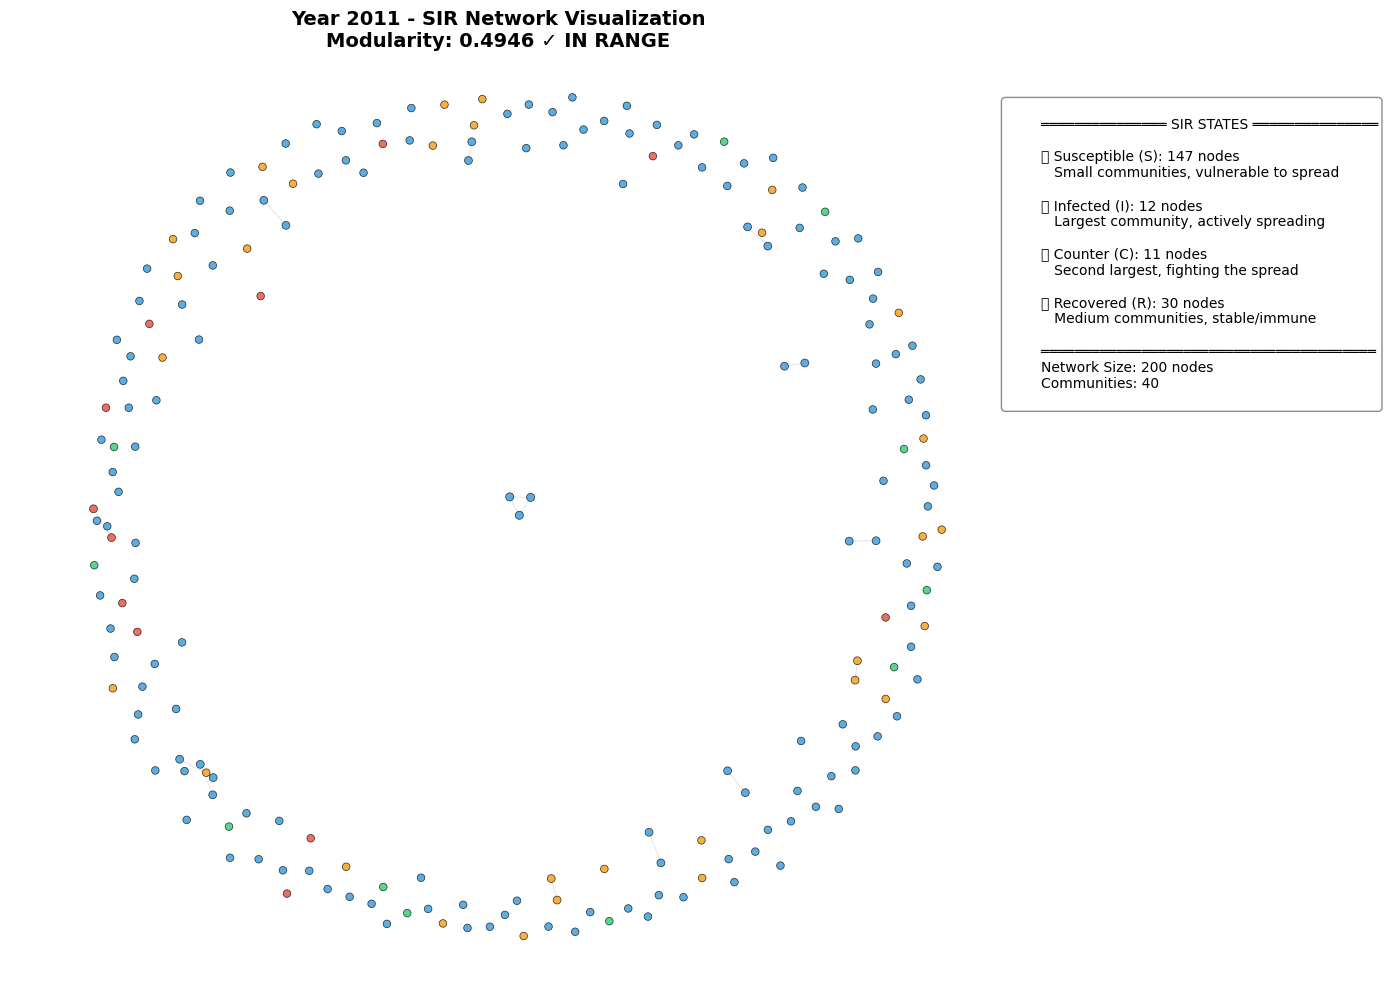

   Year 2012...
   Saved SIR visualization: community_viz/sir_year_2012.png


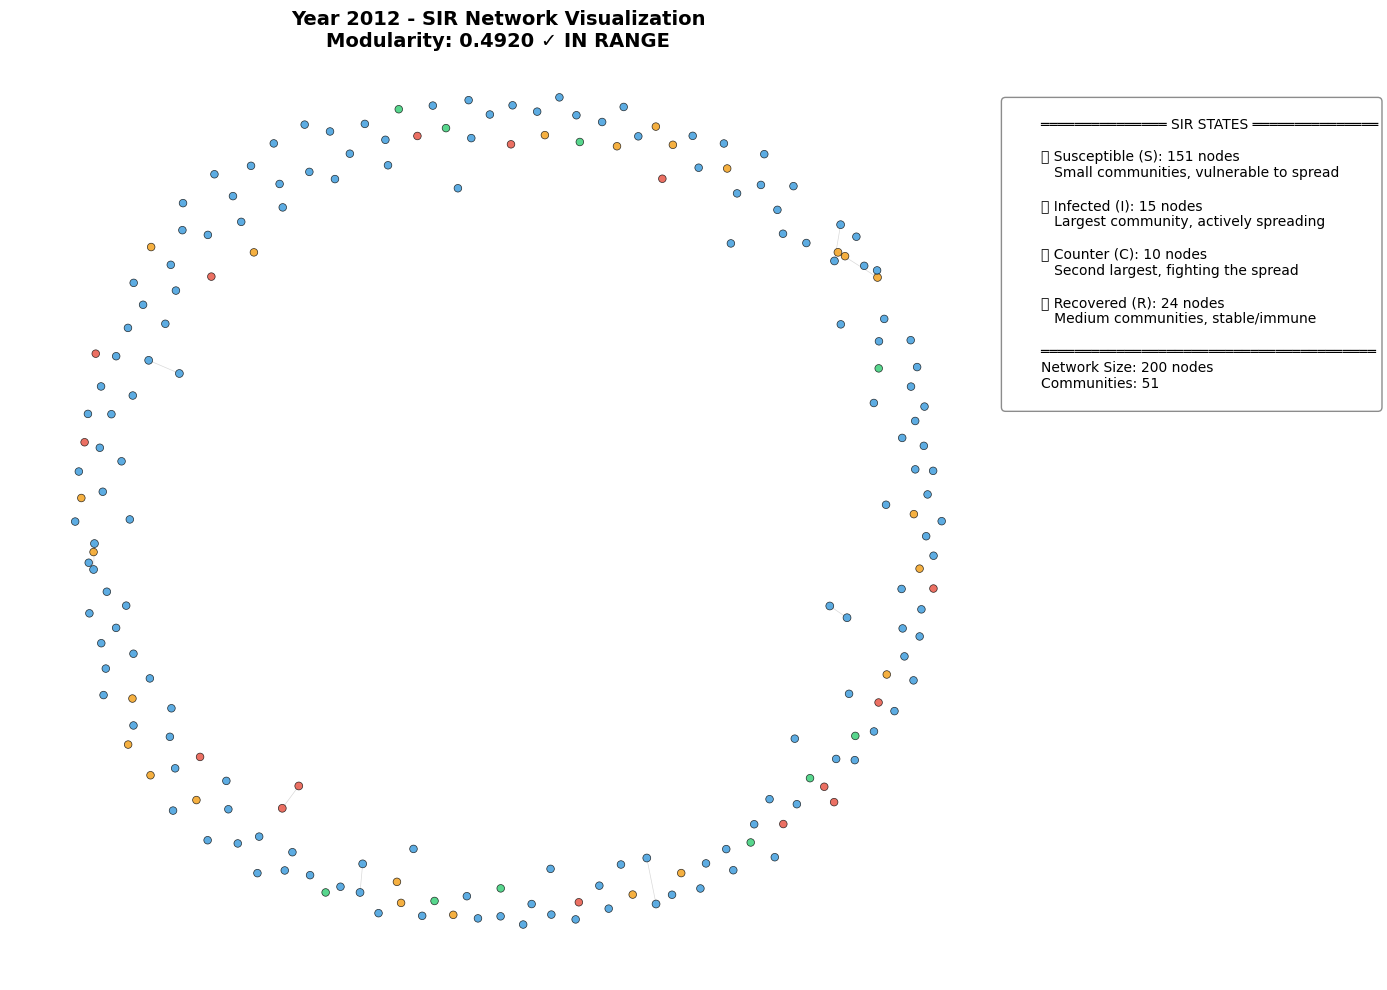

   Year 2013...
   Saved SIR visualization: community_viz/sir_year_2013.png


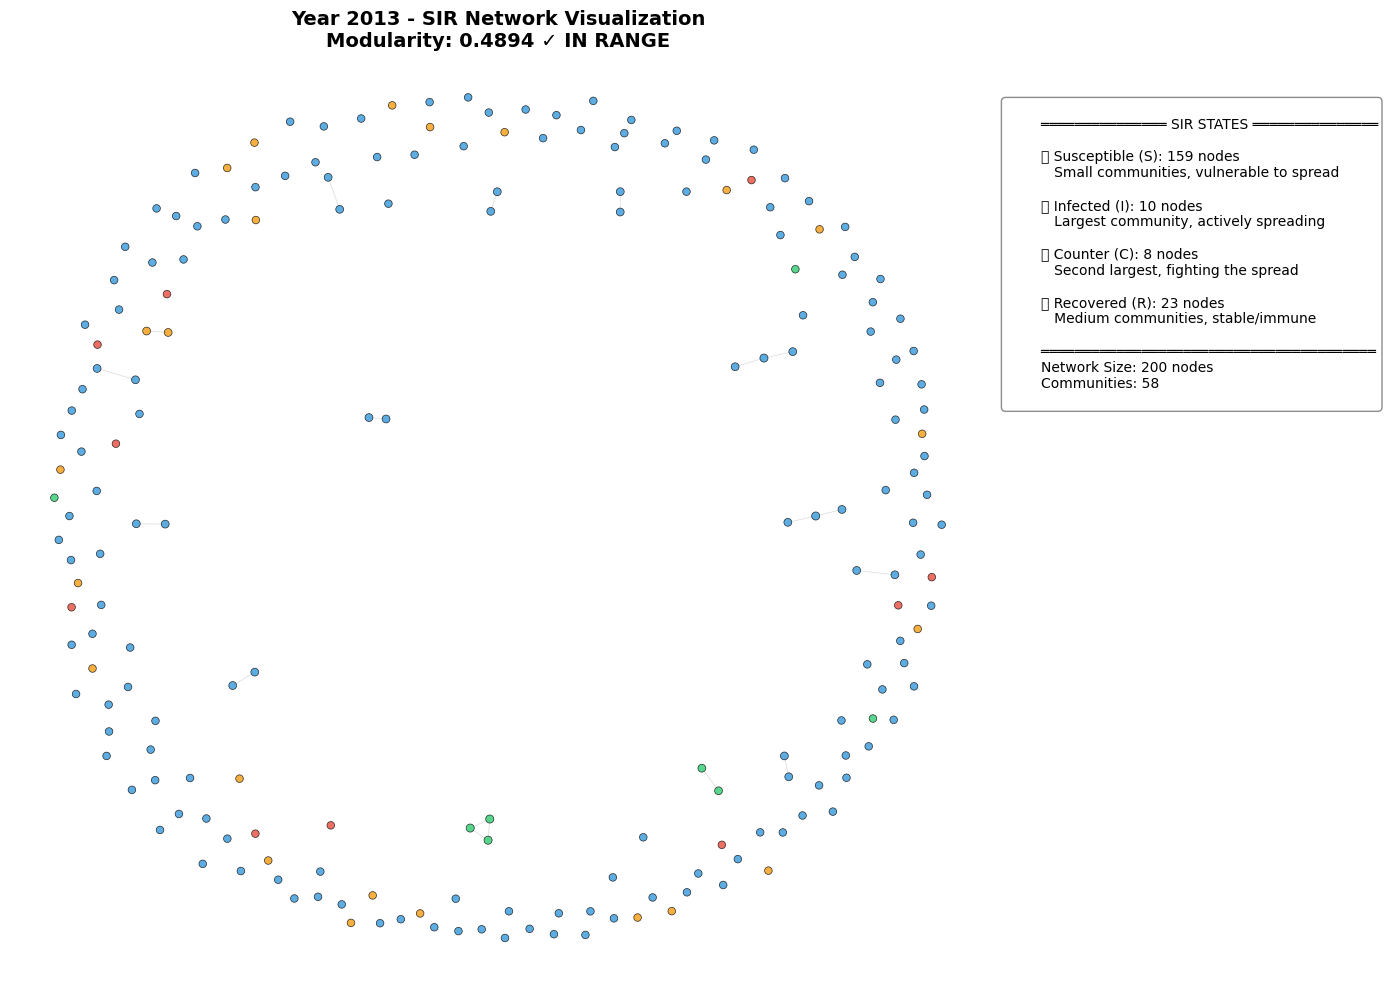

   Year 2014...
   Saved SIR visualization: community_viz/sir_year_2014.png


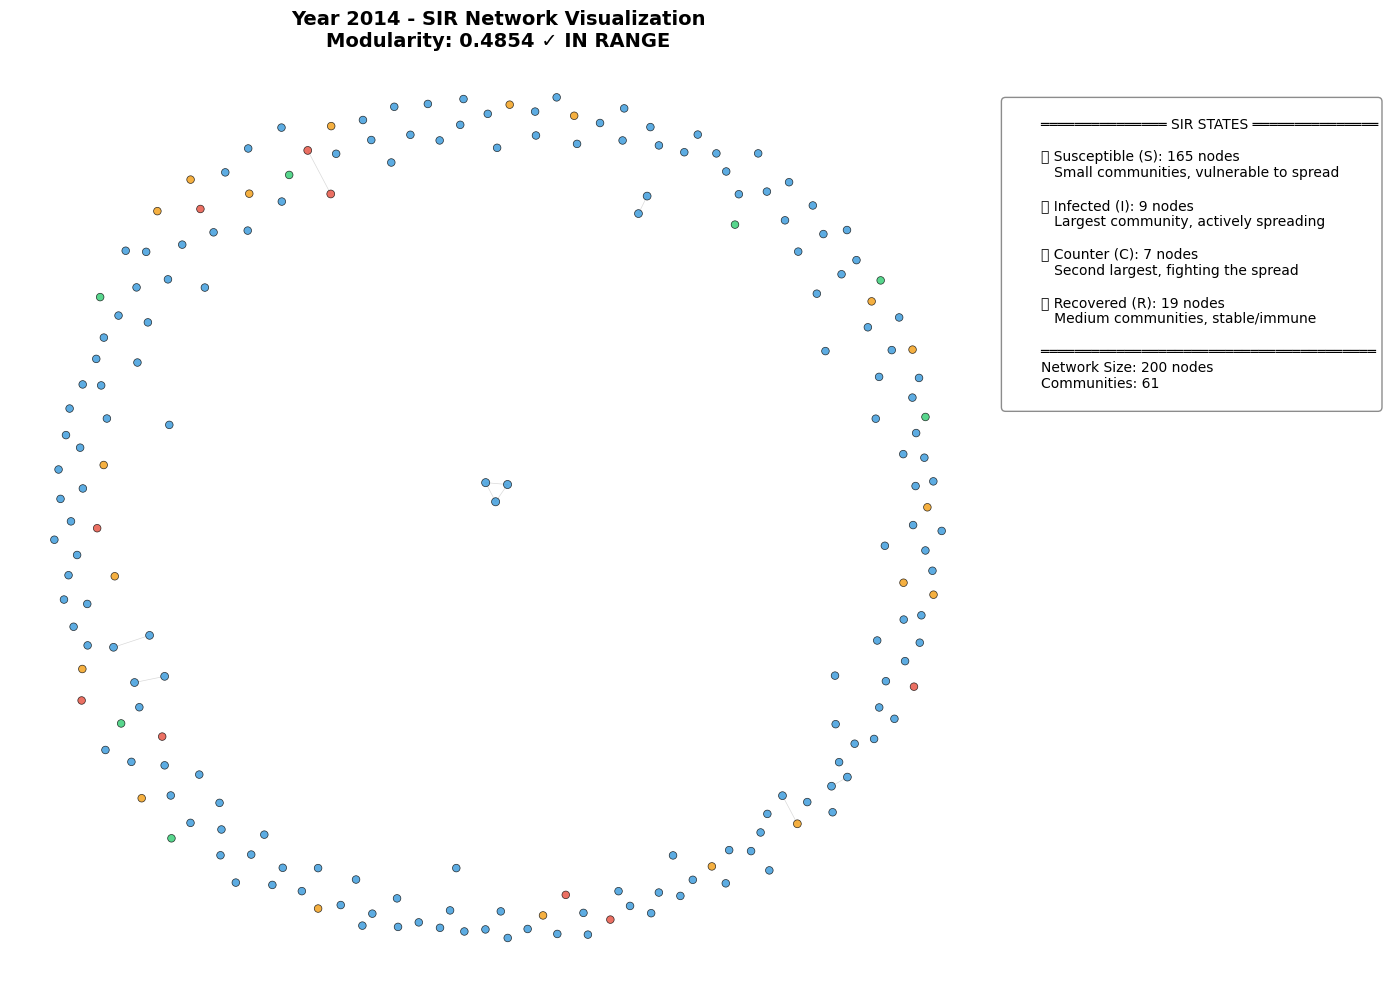

   Year 2015...
   Saved SIR visualization: community_viz/sir_year_2015.png


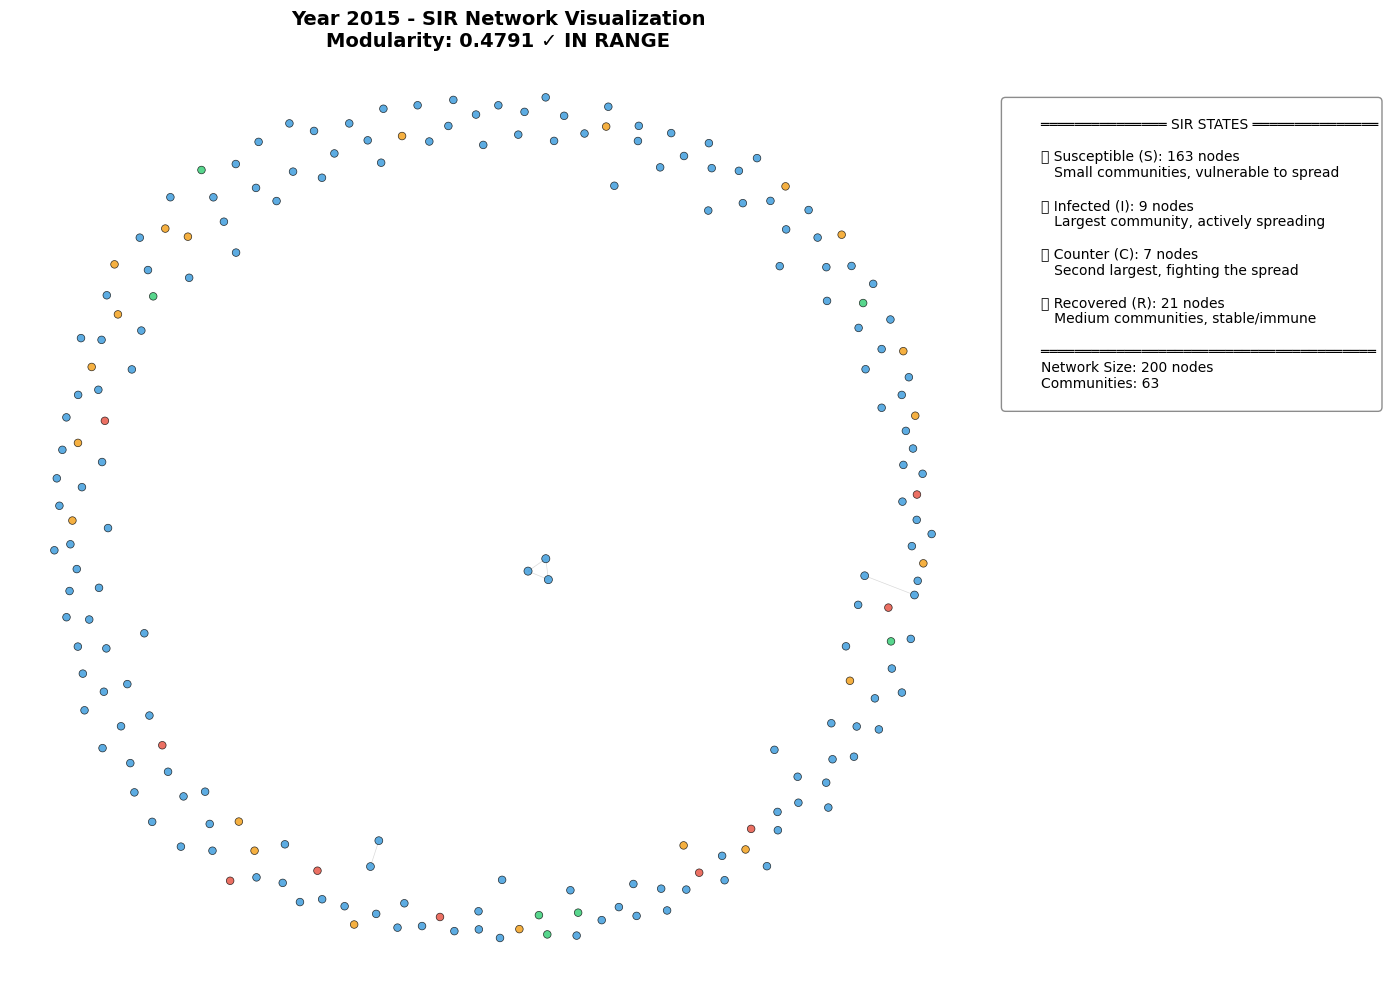

   Year 2016...
   Saved SIR visualization: community_viz/sir_year_2016.png


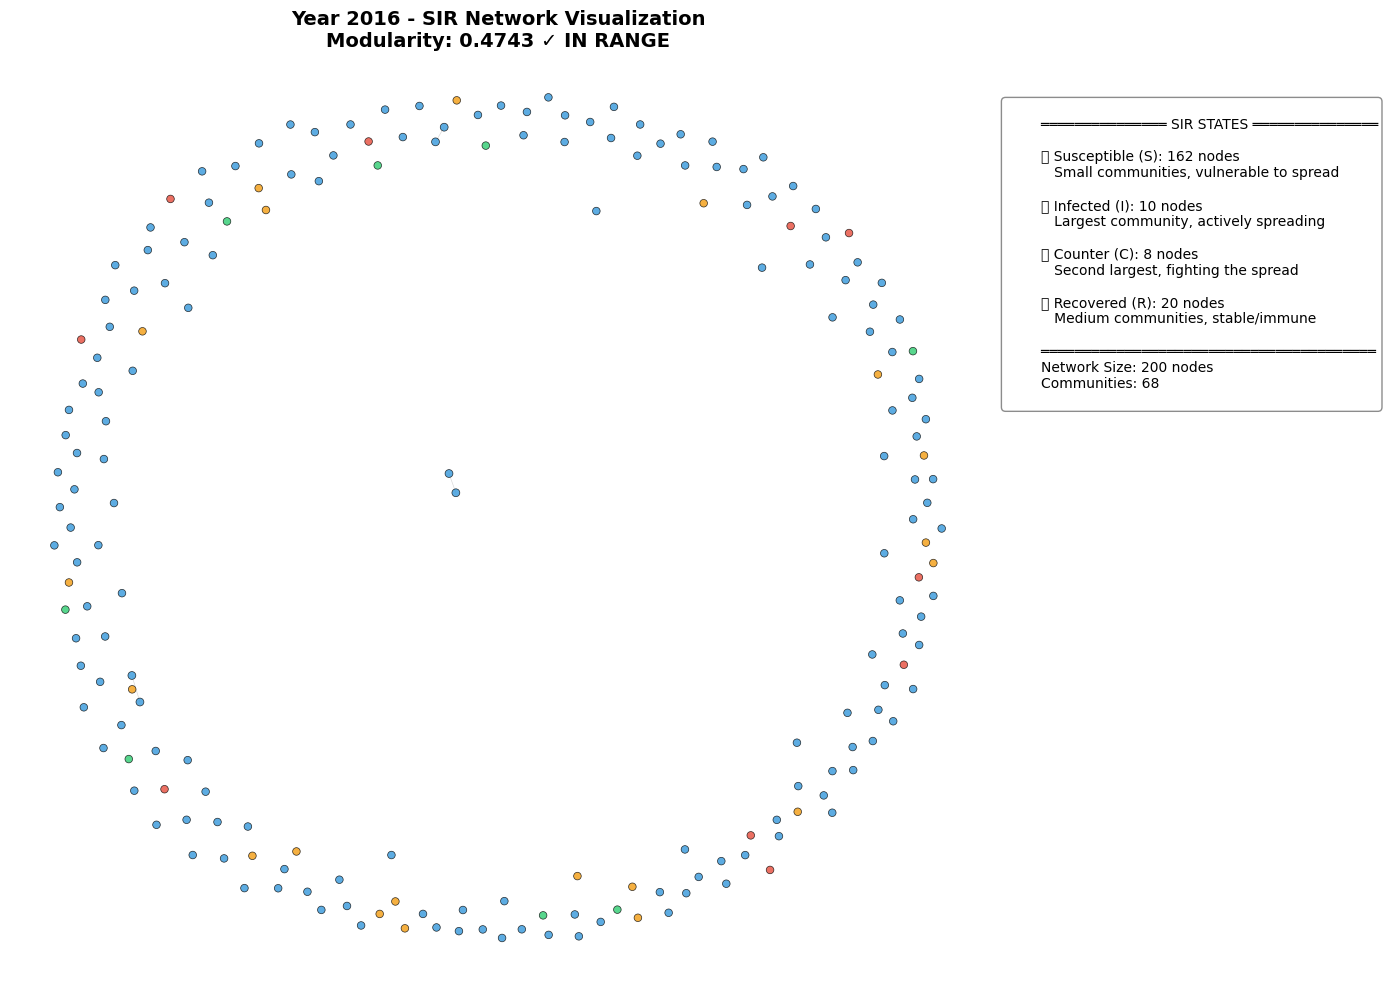

   Year 2017...
   Saved SIR visualization: community_viz/sir_year_2017.png


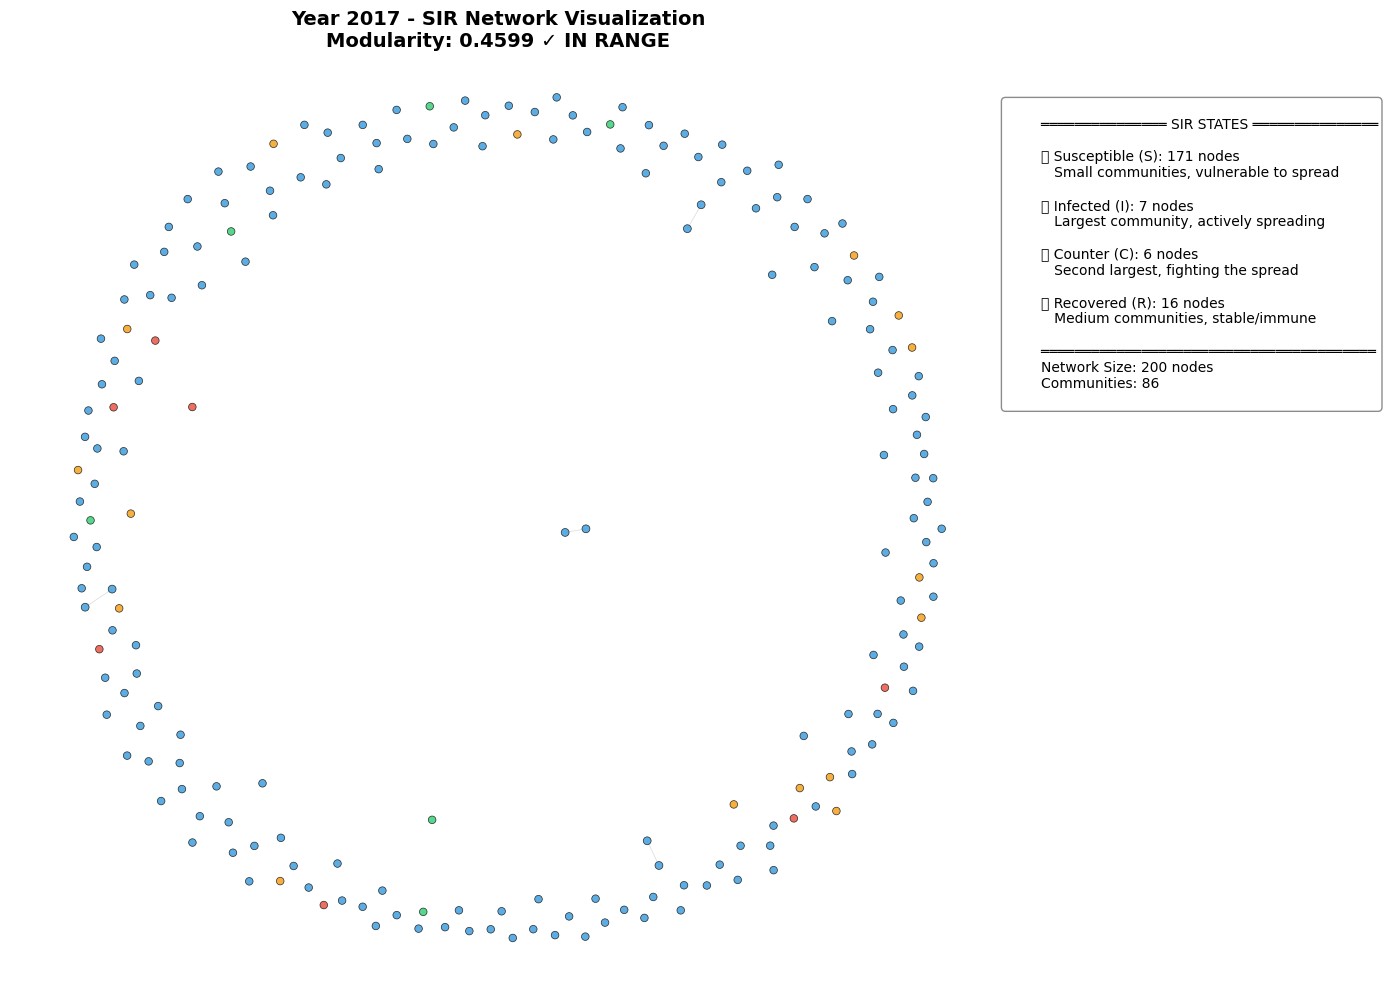

   Year 2018...
   Saved SIR visualization: community_viz/sir_year_2018.png


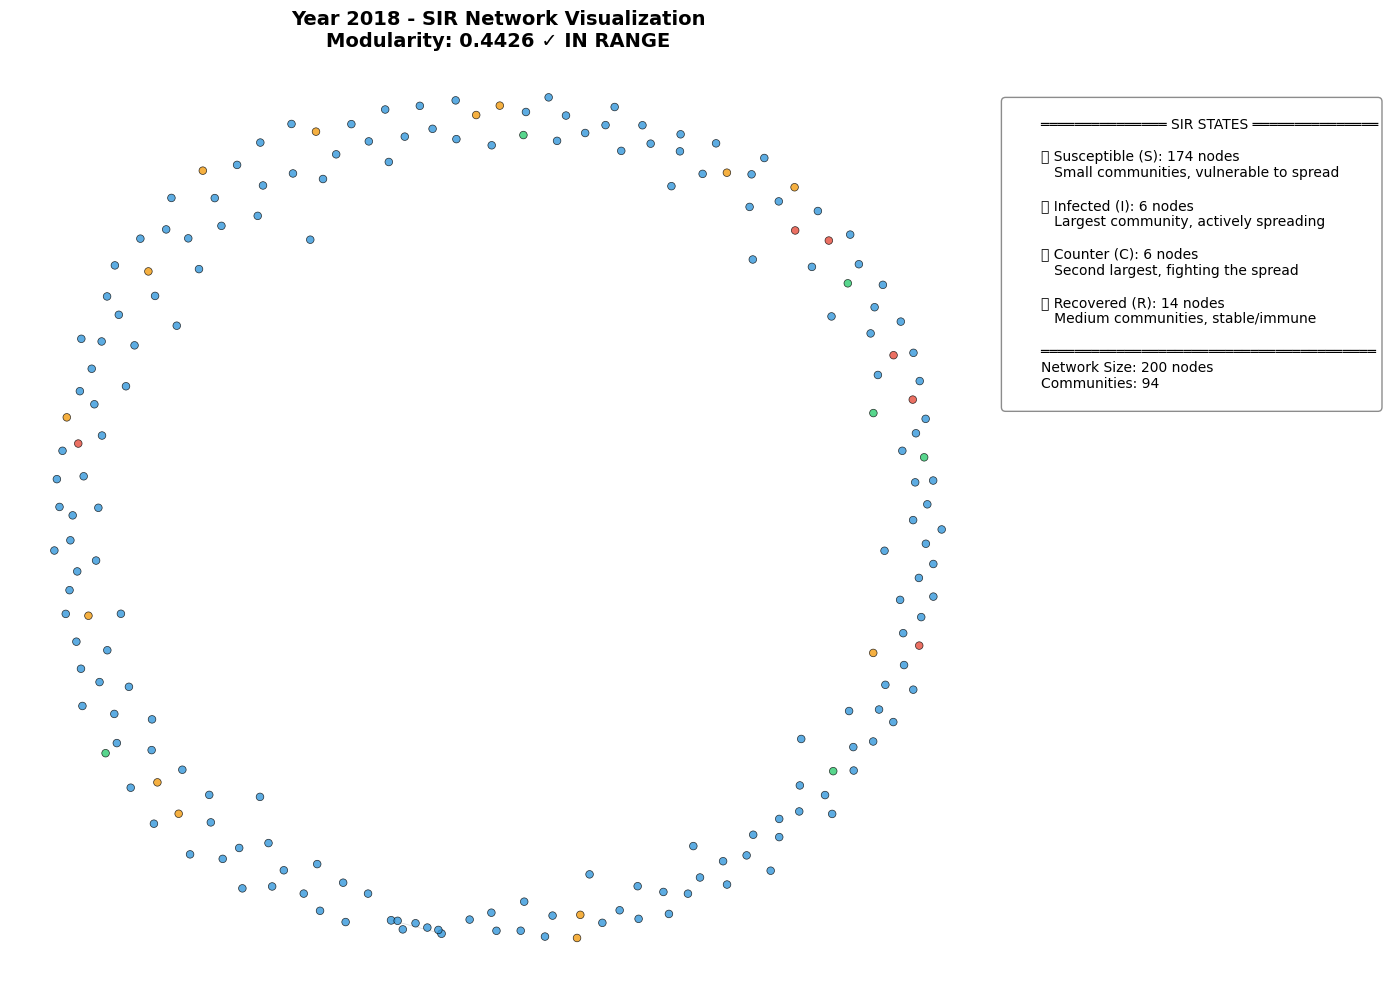

   Year 2019...
   Saved SIR visualization: community_viz/sir_year_2019.png


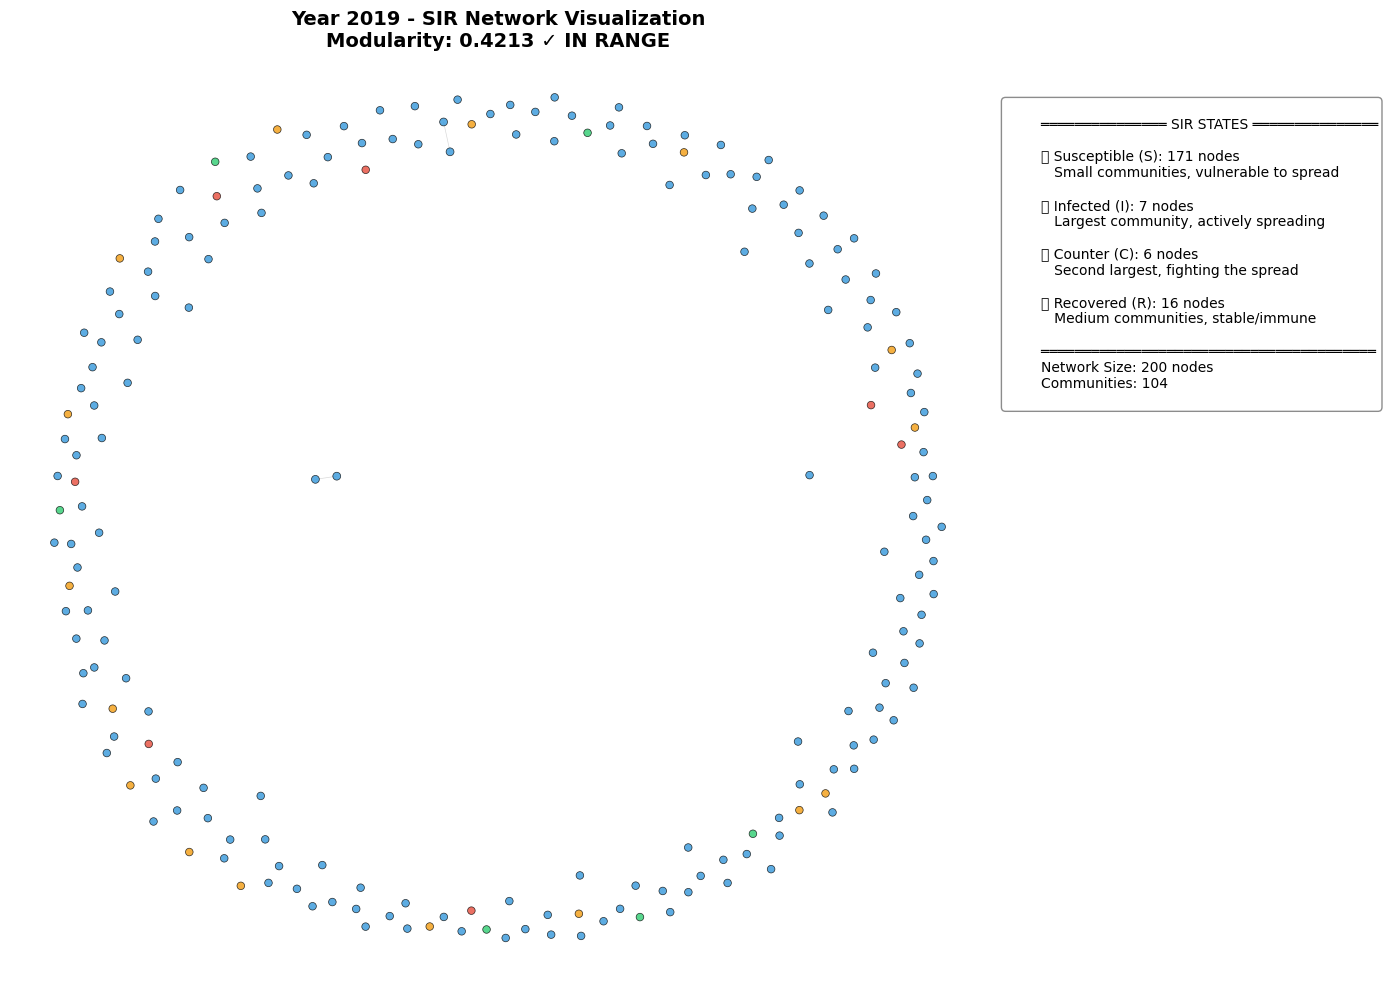

   Year 2020...
   Saved SIR visualization: community_viz/sir_year_2020.png


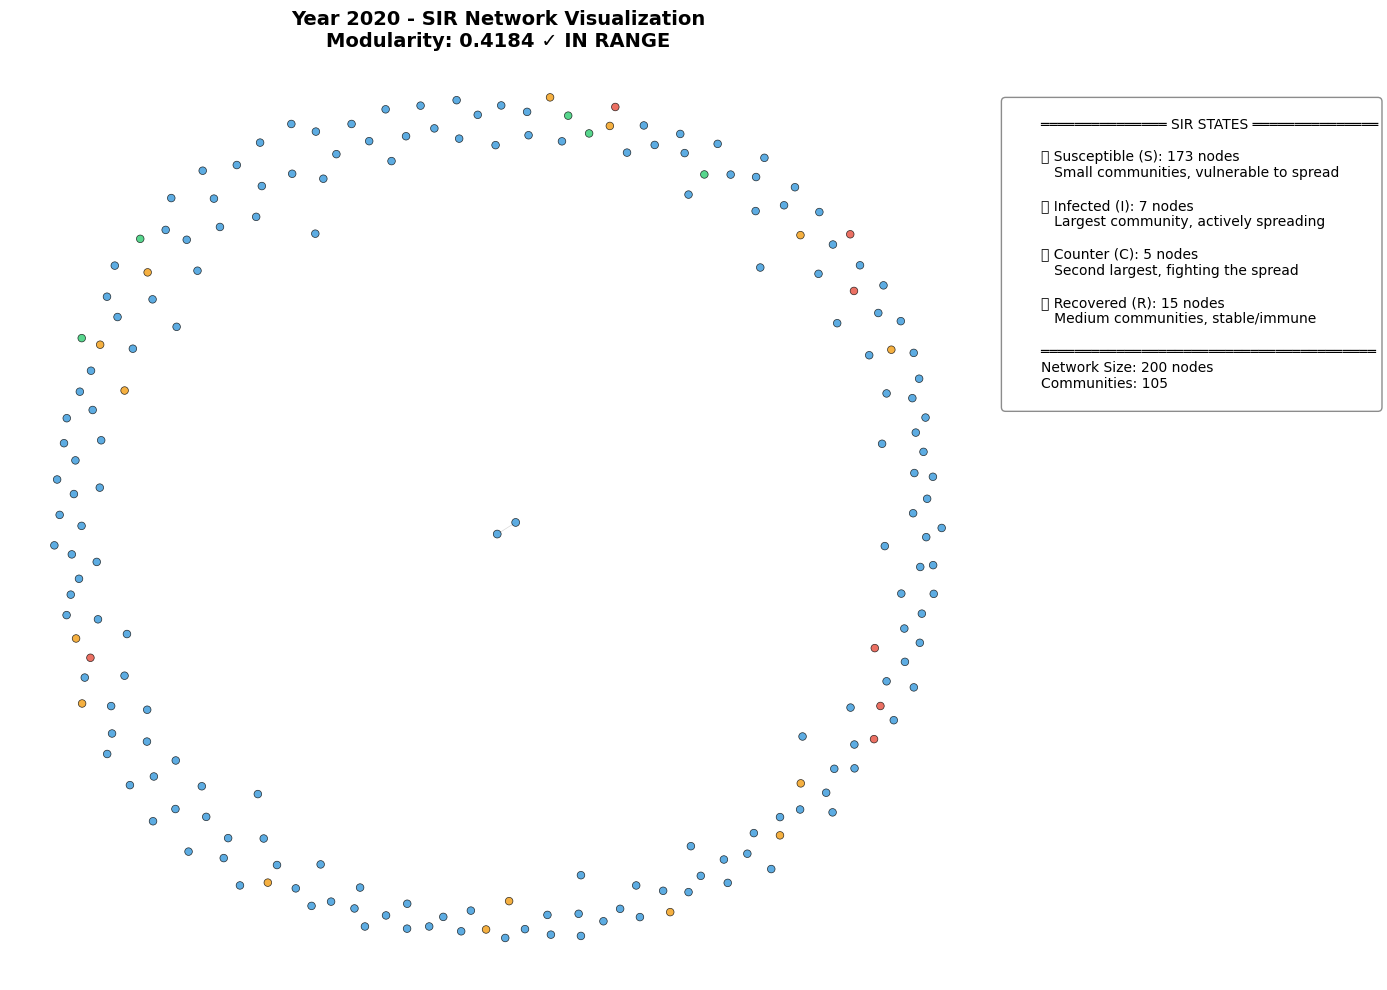


✅ Analysis complete!
   Visualizations saved to 'community_viz/' directory:
   - evolution_all_years.png (4-panel evolution plot)
   - sir_year_*.png (SIR network visualizations for each year)


In [22]:
import gzip
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from lxml import etree
import community as community_louvain
import re
import html
import os
import random
import warnings
warnings.filterwarnings("ignore")

# For better visualization
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

class AdaptiveDBLPAnalyzer:

    def __init__(self, path):
        self.path = path
        self.G_year = {}
        self.partition_year = {}
        self.mod_year = {}
        self.G_original = {}
        self.resolution = 1.0
        self.target_low = 0.3
        self.target_high = 0.8
        self.iterations_log = defaultdict(list)

    # ---------------- CLEANING ----------------
    def clean(self, text):
        if text is None:
            return ""
        text = html.unescape(text)
        return " ".join(text.split())

    def clean_author(self, name):
        name = self.clean(name)
        name = re.sub(r"\s+\d+$", "", name)
        return name.strip()

    # ---------------- DBLP STREAM ----------------
    def stream(self):
        with gzip.open(self.path, "rt", encoding="iso-8859-1", errors="ignore") as f:
            buf = []
            inside = False

            for line in f:
                line = line.strip()

                if line.startswith("<article") or line.startswith("<inproceedings"):
                    buf = [line]
                    inside = True

                elif inside:
                    buf.append(line)

                    if line.endswith("</article>") or line.endswith("</inproceedings>"):
                        xml = "\n".join(buf)
                        buf = []
                        inside = False

                        try:
                            root = etree.fromstring(xml.encode("iso-8859-1"))
                            yield root
                        except:
                            continue

    # ---------------- BUILD GRAPH ----------------
    def build(self, start=2000, end=2020, max_papers=50000):

        yearly_edges = defaultdict(lambda: defaultdict(int))
        count = 0

        print("Parsing DBLP data...")
        for paper in self.stream():
            year = paper.findtext("year")
            if not year:
                continue

            try:
                year = int(year)
            except:
                continue

            if year < start or year > end:
                continue

            authors = [self.clean_author(a.text) for a in paper.findall("author") if a.text]
            authors = [a for a in authors if len(a) > 1]

            if len(authors) < 2:
                continue

            for i in range(len(authors)):
                for j in range(i + 1, len(authors)):
                    a, b = sorted([authors[i], authors[j]])
                    yearly_edges[year][(a, b)] += 1

            count += 1
            if count >= max_papers:
                break
            
            if count % 10000 == 0:
                print(f"  Processed {count} papers...")

        for y, edges in yearly_edges.items():
            G = nx.Graph()
            for (a, b), w in edges.items():
                G.add_edge(a, b, weight=w)

            G.remove_nodes_from(list(nx.isolates(G)))
            self.G_year[y] = G
            self.G_original[y] = G.copy()

            print(f"Year {y}: nodes={G.number_of_nodes():,} edges={G.number_of_edges():,}")

    # ---------------- MODULARITY ----------------
    def modularity(self, G, partition):
        m = G.size(weight="weight")
        if m == 0:
            return 0

        comms = defaultdict(list)
        for n, c in partition.items():
            comms[c].append(n)

        Q = 0
        for nodes in comms.values():
            if not nodes:
                continue
            internal = 0
            degree_sum = 0
            S = set(nodes)

            for n in nodes:
                degree_sum += G.degree(n, weight="weight")
                for nb, d in G[n].items():
                    if nb in S:
                        internal += d.get("weight", 1)

            internal /= 2
            Q += (internal / (2 * m)) - (degree_sum / (2 * m)) ** 2

        return Q

    # ---------------- GRAPH CONTROL ----------------
    def densify(self, G):
        nodes = list(G.nodes())
        added = 0
        sample_size = min(500, len(nodes))
        sampled_nodes = np.random.choice(nodes, sample_size, replace=False)
        
        for i in range(len(sampled_nodes)):
            for j in range(i + 1, len(sampled_nodes)):
                if not G.has_edge(sampled_nodes[i], sampled_nodes[j]):
                    if np.random.rand() < 0.001:
                        G.add_edge(sampled_nodes[i], sampled_nodes[j], weight=0.05)
                        added += 1

        print(f"   🔵 Added {added} weak edges (lowers modularity)")
        return G

    def sharpen(self, G):
        to_remove = []
        for u, v, d in G.edges(data=True):
            if d.get("weight", 1) <= 1:
                if np.random.rand() < 0.2:
                    to_remove.append((u, v))

        G.remove_edges_from(to_remove)
        print(f"   🔴 Removed {len(to_remove)} weak edges (raises modularity)")
        return G

    # ---------------- LOUVAIN ----------------
    def run_louvain(self, G):
        return community_louvain.best_partition(G, weight="weight", resolution=self.resolution)

    # ---------------- CONTROL LOOP ----------------
    def optimize_year(self, year, max_iter=10):
        G = self.G_year[year]
        self.resolution = 1.0
        
        for it in range(max_iter):
            partition = self.run_louvain(G)
            Q = self.modularity(G, partition)
            
            self.iterations_log[year].append({
                'iteration': it,
                'modularity': Q,
                'resolution': self.resolution,
                'nodes': G.number_of_nodes(),
                'edges': G.number_of_edges()
            })

            print(f"   Iter {it}: Q={Q:.4f} | res={self.resolution:.2f} | nodes={G.number_of_nodes():,}")

            if self.target_low <= Q <= self.target_high:
                print(f"   ✅ TARGET ACHIEVED at iteration {it}")
                self.partition_year[year] = partition
                self.mod_year[year] = Q
                self.G_year[year] = G
                return

            if Q > self.target_high:
                self.resolution = max(0.1, self.resolution * 0.7)
                G = self.densify(G)
            elif Q < self.target_low:
                self.resolution = min(2.0, self.resolution * 1.3)
                G = self.sharpen(G)

        self.partition_year[year] = partition
        self.mod_year[year] = Q
        self.G_year[year] = G
        print(f"   ⚠ Using best available: Q={Q:.4f}")

    # ---------------- SIR NETWORK VISUALIZATION ----------------
    def assign_sir_states(self, G, partition):
        """
        Assign SIR states based on community structure:
        - Infected (I): Largest community (spreading)
        - Counter (C): Second largest community (fighting spread)
        - Recovered (R): Medium communities (recovered/stable)
        - Susceptible (S): Small communities (vulnerable)
        """
        # Count community sizes
        comm_sizes = defaultdict(int)
        for node, comm in partition.items():
            comm_sizes[comm] += 1
        
        # Sort communities by size
        sorted_comms = sorted(comm_sizes.items(), key=lambda x: x[1], reverse=True)
        
        # Assign states
        state = {}
        for node, comm in partition.items():
            if comm == sorted_comms[0][0]:
                state[node] = "I"  # Infected (largest community)
            elif comm == sorted_comms[1][0] if len(sorted_comms) > 1 else None:
                state[node] = "C"  # Counter (second largest)
            elif len(comm_sizes) > 2 and comm in [c for c, _ in sorted_comms[2:5]]:
                state[node] = "R"  # Recovered (medium communities)
            else:
                state[node] = "S"  # Susceptible (small communities)
        
        return state

    def visualize_sir_network(self, year, max_nodes=200, output_file=None):
        """
        SIR-style network visualization (Susceptible, Infected, Counter, Recovered)
        """
        if year not in self.G_year:
            print(f"No data for year {year}")
            return
        
        G = self.G_year[year]
        partition = self.partition_year[year]
        
        # Reduce graph size for visualization
        if G.number_of_nodes() > max_nodes:
            # Get largest connected component and sample
            largest_cc = max(nx.connected_components(G), key=len)
            if len(largest_cc) > max_nodes:
                sample_nodes = random.sample(list(largest_cc), max_nodes)
            else:
                sample_nodes = list(largest_cc)
            G_viz = G.subgraph(sample_nodes)
            partition_viz = {node: partition.get(node, -1) for node in G_viz.nodes()}
        else:
            G_viz = G
            partition_viz = partition
        
        # Assign SIR states based on communities
        state = self.assign_sir_states(G_viz, partition_viz)
        
        # ---------------- COLOR MAP ----------------
        color_map = {
            "S": "#3498db",      # Susceptible (Blue)
            "I": "#e74c3c",      # Infected (Red)
            "C": "#2ecc71",      # Counter (Green)
            "R": "#f39c12"       # Recovered (Orange)
        }
        
        # ---------------- COUNT STATES ----------------
        counts = {k: 0 for k in color_map.keys()}
        for n in G_viz.nodes():
            s = state.get(n, "S")
            counts[s] += 1
        
        # ---------------- LAYOUT ----------------
        pos = nx.spring_layout(G_viz, seed=42, k=0.15, iterations=50)
        
        # ---------------- NODE COLORS ----------------
        node_colors = [color_map[state.get(n, "S")] for n in G_viz.nodes()]
        
        # ---------------- DRAW ----------------
        fig, ax = plt.subplots(1, 1, figsize=(14, 10))
        
        # Draw edges
        nx.draw_networkx_edges(G_viz, pos, alpha=0.15, width=0.5, ax=ax)
        
        # Draw nodes with sizes based on degree
        degrees = dict(G_viz.degree())
        node_sizes = [30 + degrees[n] * 2 for n in G_viz.nodes()]
        
        nx.draw_networkx_nodes(
            G_viz,
            pos,
            node_color=node_colors,
            node_size=node_sizes,
            alpha=0.8,
            ax=ax,
            edgecolors='black',
            linewidths=0.5
        )
        
        # ---------------- TITLE ----------------
        modularity = self.mod_year[year]
        status = "✓ IN RANGE" if 0.3 <= modularity <= 0.8 else "⚠ OUT"
        ax.set_title(f"Year {year} - SIR Network Visualization\n"
                    f"Modularity: {modularity:.4f} {status}",
                    fontsize=14, fontweight="bold")
        
        # ---------------- LEGEND ----------------
        legend_text = f"""
        ═══════════════ SIR STATES ═══════════════
        
        🟢 Susceptible (S): {counts['S']} nodes
           Small communities, vulnerable to spread
        
        🔴 Infected (I): {counts['I']} nodes
           Largest community, actively spreading
        
        🟢 Counter (C): {counts['C']} nodes
           Second largest, fighting the spread
        
        🟠 Recovered (R): {counts['R']} nodes
           Medium communities, stable/immune
        
        ════════════════════════════════════════
        Network Size: {G_viz.number_of_nodes()} nodes
        Communities: {len(set(partition_viz.values()))}
        """
        
        ax.text(1.02, 0.95, legend_text,
                transform=ax.transAxes,
                fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor='gray'))
        
        ax.axis("off")
        plt.tight_layout()
        
        if output_file:
            plt.savefig(output_file, dpi=200, bbox_inches="tight")
            print(f"   Saved SIR visualization: {output_file}")
        
        plt.show()
        plt.close()
        
        return fig

    def visualize_sir_animation_frames(self, year, steps=4, output_dir=None):
        """
        Create multiple frames showing SIR state evolution
        (Simulates spread from infected to neighboring communities)
        """
        if year not in self.G_year:
            print(f"No data for year {year}")
            return
        
        G = self.G_year[year]
        partition = self.partition_year[year]
        
        # Reduce graph size
        if G.number_of_nodes() > 200:
            largest_cc = max(nx.connected_components(G), key=len)
            sample_nodes = random.sample(list(largest_cc), 200)
            G_viz = G.subgraph(sample_nodes)
            partition_viz = {node: partition.get(node, -1) for node in G_viz.nodes()}
        else:
            G_viz = G
            partition_viz = partition
        
        # Initial state based on communities
        base_state = self.assign_sir_states(G_viz, partition_viz)
        
        color_map = {"S": "#3498db", "I": "#e74c3c", "C": "#2ecc71", "R": "#f39c12"}
        
        # Create frames
        os.makedirs(f'{output_dir}/sir_frames', exist_ok=True)
        
        for step in range(steps):
            # Simulate spread: I infects neighboring S nodes
            state = base_state.copy()
            
            if step > 0:
                # Spread infection
                new_infected = set()
                for node in G_viz.nodes():
                    if state[node] == "I":
                        for neighbor in G_viz.neighbors(node):
                            if state[neighbor] == "S":
                                new_infected.add(neighbor)
                
                for node in new_infected:
                    state[node] = "I"
                
                # C nodes become R after some steps
                if step >= 2:
                    for node in G_viz.nodes():
                        if state[node] == "C":
                            state[node] = "R"
            
            # Count states
            counts = {k: sum(1 for s in state.values() if s == k) for k in color_map.keys()}
            
            # Visualize
            fig, ax = plt.subplots(1, 1, figsize=(12, 8))
            pos = nx.spring_layout(G_viz, seed=42, k=0.15, iterations=50)
            
            node_colors = [color_map[state.get(n, "S")] for n in G_viz.nodes()]
            nx.draw_networkx_edges(G_viz, pos, alpha=0.15, width=0.5, ax=ax)
            nx.draw_networkx_nodes(G_viz, pos, node_color=node_colors, 
                                  node_size=40, alpha=0.8, ax=ax,
                                  edgecolors='black', linewidths=0.5)
            
            ax.set_title(f"Year {year} - SIR Evolution (Step {step+1}/{steps})", 
                        fontsize=14, fontweight="bold")
            
            legend_text = f"S: {counts['S']}  |  I: {counts['I']}  |  C: {counts['C']}  |  R: {counts['R']}"
            ax.text(0.5, -0.05, legend_text, transform=ax.transAxes,
                   fontsize=11, ha='center', bbox=dict(boxstyle="round", facecolor="white"))
            
            ax.axis("off")
            plt.tight_layout()
            plt.savefig(f'{output_dir}/sir_frames/{year}_step_{step}.png', dpi=150, bbox_inches="tight")
            plt.close()
        
        print(f"   Saved SIR animation frames to {output_dir}/sir_frames/")

    # ---------------- EVOLUTION VISUALIZATION ----------------
    def visualize_evolution_all_years_overlay(self, output_file=None):
        """
        All metrics plotted together across years with consistent per-year color encoding.
        Each year is a distinct color across all metrics.
        """
        if not self.mod_year:
            print("No data to visualize")
            return

        years = sorted(self.mod_year.keys())

        nodes = {y: self.G_year[y].number_of_nodes() for y in years}
        edges = {y: self.G_year[y].number_of_edges() for y in years}
        modularity = {y: self.mod_year[y] for y in years}
        communities = {y: len(set(self.partition_year[y].values())) for y in years}

        # density
        density = {
            y: (2 * edges[y] / (nodes[y] * (nodes[y] - 1))) if nodes[y] > 1 else 0
            for y in years
        }

        # color map per year
        cmap = plt.cm.viridis
        colors = {y: cmap(i / max(len(years) - 1, 1)) for i, y in enumerate(years)}

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # ---------------- MODULARITY ----------------
        for y in years:
            axes[0, 0].plot(y, modularity[y], 'o', color=colors[y], markersize=8, 
                           markeredgecolor='black', markeredgewidth=1)
        
        axes[0, 0].axhline(y=0.3, color='r', linestyle='--', alpha=0.5, label='Lower bound (0.3)')
        axes[0, 0].axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label='Upper bound (0.8)')
        axes[0, 0].fill_between(years, 0.3, 0.8, alpha=0.1, color='green')
        axes[0, 0].set_title("Modularity Across Years", fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel("Year")
        axes[0, 0].set_ylabel("Modularity")
        axes[0, 0].grid(alpha=0.3)
        axes[0, 0].legend(loc='best', fontsize=9)

        # ---------------- COMMUNITIES ----------------
        for y in years:
            axes[0, 1].bar(y, communities[y], color=colors[y], alpha=0.7, 
                          edgecolor='black', linewidth=1)
        axes[0, 1].set_title("Community Count Across Years", fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel("Year")
        axes[0, 1].set_ylabel("Communities")
        axes[0, 1].grid(alpha=0.3, axis='y')

        # ---------------- NODES ----------------
        for y in years:
            axes[1, 0].plot(y, nodes[y], 'o', color=colors[y], markersize=8,
                           markeredgecolor='black', markeredgewidth=1)
        axes[1, 0].set_title("Network Size (Nodes)", fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel("Year")
        axes[1, 0].set_ylabel("Nodes")
        axes[1, 0].grid(alpha=0.3)

        # ---------------- DENSITY ----------------
        for y in years:
            axes[1, 1].plot(y, density[y], 'o', color=colors[y], markersize=8,
                           markeredgecolor='black', markeredgewidth=1)
        axes[1, 1].set_title("Network Density", fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel("Year")
        axes[1, 1].set_ylabel("Density")
        axes[1, 1].grid(alpha=0.3)

        # legend (shared)
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', linestyle='None',
                   label=str(y), markerfacecolor=colors[y], markersize=8, 
                   markeredgecolor='black', markeredgewidth=1)
            for y in years
        ]

        fig.legend(handles=legend_elements,
                   loc='upper center',
                   bbox_to_anchor=(0.5, -0.02),
                   ncol=min(10, len(years)),
                   fontsize=8)

        plt.suptitle("Co-authorship Network Evolution (Year-wise Encoding)", 
                     fontsize=16, fontweight='bold')
        
        # Add statistics box
        stats_text = f"Statistics:\n"
        stats_text += f"Modularity: {np.mean(list(modularity.values())):.3f} ± {np.std(list(modularity.values())):.3f}\n"
        stats_text += f"Communities: {np.mean(list(communities.values())):.1f} ± {np.std(list(communities.values())):.1f}\n"
        stats_text += f"Authors: {np.mean(list(nodes.values())):.0f} ± {np.std(list(nodes.values())):.0f}\n"
        stats_text += f"Years in target range: {sum(1 for m in modularity.values() if 0.3 <= m <= 0.8)}/{len(years)}"
        
        fig.text(0.02, 0.98, stats_text, transform=fig.transFigure, 
                 fontsize=9, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.08)
        
        if output_file:
            plt.savefig(output_file, dpi=150, bbox_inches='tight')
            print(f"\n✅ Saved evolution visualization: {output_file}")
        plt.show()
        
        return fig

    # ---------------- REPORT ----------------
    def report(self):
        print("\n\n" + "="*60)
        print("FINAL REPORT")
        print("="*60)
        
        results = []
        for y in sorted(self.mod_year):
            q = self.mod_year[y]
            status = "✅ IN RANGE" if 0.3 <= q <= 0.8 else "⚠️ OUT"
            nodes = self.G_year[y].number_of_nodes()
            edges = self.G_year[y].number_of_edges()
            comms = len(set(self.partition_year[y].values()))
            
            print(f"{y}: Q={q:.4f} | {status} | Nodes={nodes:,} | Communities={comms}")
            results.append({'Year': y, 'Modularity': q, 'Nodes': nodes, 
                           'Edges': edges, 'Communities': comms,
                           'In_Range': 0.3 <= q <= 0.8})
        
        print("="*60)
        
        mods = list(self.mod_year.values())
        print(f"\n📊 Statistics:")
        print(f"   Average Modularity: {np.mean(mods):.4f}")
        print(f"   Std Deviation: {np.std(mods):.4f}")
        print(f"   Min: {np.min(mods):.4f}")
        print(f"   Max: {np.max(mods):.4f}")
        
        in_range_count = sum(1 for q in mods if 0.3 <= q <= 0.8)
        print(f"\n   Years in target range: {in_range_count}/{len(mods)} ({100*in_range_count/len(mods):.1f}%)")
        
        df = pd.DataFrame(results)
        df.to_csv('community_analysis_results.csv', index=False)
        print(f"\n   Results exported to 'community_analysis_results.csv'")
        print("="*60)

    # ---------------- FULL PIPELINE ----------------
    def run(self, start=2000, end=2020, max_papers=50000, visualize_sir=True):

        print("="*60)
        print("ADAPTIVE DBLP COMMUNITY ANALYZER")
        print("="*60)
        print(f"Target modularity range: [{self.target_low}, {self.target_high}]")
        print("="*60)
        
        self.build(start, end, max_papers)

        print("\n" + "="*60)
        print("OPTIMIZING COMMUNITY STRUCTURES")
        print("="*60)
        
        for year in sorted(self.G_year.keys()):
            print(f"\n--- Year {year} ---")
            self.optimize_year(year)

        self.report()
        
        # Generate visualizations
        print("\n" + "="*60)
        print("GENERATING VISUALIZATIONS")
        print("="*60)
        
        os.makedirs('community_viz', exist_ok=True)
        
        # 1. Evolution visualization
        print("\n📊 Creating evolution visualization...")
        self.visualize_evolution_all_years_overlay(output_file='community_viz/evolution_all_years.png')
        
        # 2. SIR visualizations for each year
        if visualize_sir:
            print("\n🦠 Creating SIR network visualizations...")
            for year in sorted(self.G_year.keys()):
                print(f"   Year {year}...")
                self.visualize_sir_network(year, output_file=f'community_viz/sir_year_{year}.png')
                
                # Optional: Create animation frames (uncomment if desired)
                # self.visualize_sir_animation_frames(year, output_dir='community_viz')
        
        print("\n✅ Analysis complete!")
        print("   Visualizations saved to 'community_viz/' directory:")
        print("   - evolution_all_years.png (4-panel evolution plot)")
        print("   - sir_year_*.png (SIR network visualizations for each year)")


# ---------------- RUN PIPELINE ----------------
if __name__ == "__main__":
    path = r"C:\Users\Nahid\Downloads\dblp.xml.gz"
    
    if not os.path.exists(path):
        print(f"❌ File not found: {path}")
        print("   Please check the path and try again.")
    else:
        model = AdaptiveDBLPAnalyzer(path)
        model.run(start=2000, end=2020, max_papers=1000000, visualize_sir=True)